# German Credit Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder

from models.mlp import BlackBoxModel

pd.set_option('display.max_columns', None)

%reload_ext autoreload
%autoreload 2

import sys, os

# 假设你现在的 notebook 在项目根目录下
sys.path.append(os.path.abspath("."))



In [2]:
def set_seed(seed=42):
    import os, random, numpy as np, torch
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)          # Python 随机
    np.random.seed(seed)       # NumPy 随机
    torch.manual_seed(seed)    # PyTorch CPU 随机
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed=42

# Read and Process Data

In [3]:
df_ = pd.read_csv('data/german_credit/german_credit_data.csv')
df = df_.copy()

target_name = 'Risk'
target = df[target_name].replace({'good': 0, 'bad': 1})

df['Risk'] = target

字符型特征 → 数值型编码（Label Encoding）;缺失值 → 填补（字符型用 "Unknown"，数值型用中位数）

In [4]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_mappings = {}

# 顺序映射
saving_map = {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}
checking_map = {"little": 1, "moderate": 2, "rich": 3}
housing_map = {"free": 0, "rent": 1, "own": 2}

for column in df.columns:
    if column is not target_name and df[column].dtype == 'object':
        if column == "Saving accounts":
            df[column] = df[column].map(saving_map)   # 未匹配的保持 NaN
        elif column == "Checking account":
            df[column] = df[column].map(checking_map)
        elif column == "Housing":
            df[column] = df[column].map(housing_map)
        else:
            df[column] = label_encoder.fit_transform(df[column].astype(str))

# ⚠️ 关键：只在最后一步处理 NaN
for column in df.columns:
    if df[column].isna().any():
        median_val = df[column].median()
        df[column] = df[column].fillna(median_val).astype(int)
# print(df.median())
print(df.head())


   Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount   
0   67    1    2        2                1                 1           1169  \
1   22    0    2        2                1                 2           5951   
2   49    1    1        2                1                 2           2096   
3   45    1    2        0                1                 1           7882   
4   53    1    2        0                1                 1           4870   

   Duration  Purpose  Risk  
0         6        5     0  
1        48        5     1  
2        12        3     0  
3        42        4     0  
4        24        1     1  


# Model Training

In [5]:
features = [
    'Age', 
    'Sex', 
    'Job', 
    'Housing', 
    'Saving accounts', 
    'Checking account',
    'Credit amount', 
    'Duration', 
    'Purpose', 
]

df_X = df[features].copy()
df_y = target

三层全连接的 MLP (dnn),作为“黑箱”的替代

In [6]:
set_seed(seed)
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=seed)

std = X_train.std()
mean = X_train.mean()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)


# 在初始化模型前强制重设随机数
torch.manual_seed(seed)

# Initialize the model, loss function, and optimizer
model = BlackBoxModel(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 300
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

    # Convert outputs to binary using 0.5 as threshold
    y_pred_tensor = (test_outputs > 0.5).float()
    correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
    accuracy = correct_predictions / y_test_tensor.shape[0]

accuracy.item()

0.75

In [7]:
stats_df = pd.DataFrame({
    "mean": mean,
    "std": std
})
print(stats_df)

                        mean          std
Age                 35.55875    11.411587
Sex                  0.68250     0.465795
Job                  1.93000     0.654320
Housing              1.60750     0.675658
Saving accounts      1.38875     0.819123
Checking account     1.79375     0.535322
Credit amount     3360.61875  2898.174863
Duration            21.09500    11.807211
Purpose              2.86250     1.993379


# 用原来的DCE生成baseline

In [8]:
sample_num = 100
delta = 0.1
alpha = 0.05
N=10
explain_columns = [
    'Age', 
    'Sex', 
    'Job', 
    'Housing', 
    'Saving accounts', 
    'Checking account',
    'Credit amount', 
    'Duration', 
    'Purpose', 
]
set_seed(seed)
indice = (X_test.sample(sample_num, random_state=seed)).index
# # 验证抽样是否固定
print(indice[:10])   # 输出前10个索引，运行两次应该一模一样
df_explain = X_test.loc[indice]

# X = X_test.loc[indice].values
y = model(torch.FloatTensor(df_explain.values))

y_target = torch.distributions.beta.Beta(0.1, 0.9).sample((sample_num,))

y_true = y_test.loc[indice]
# print(y_target)    #检查是否每次抽样结果一样

Index([436, 899, 346, 60, 867, 432, 543, 361, 486, 277], dtype='int64')


In [9]:
indices = (X_test.sample(sample_num, random_state=seed)).index
y_subset = y_test.loc[indices]
print(y_subset.value_counts())

Risk
0    72
1    28
Name: count, dtype: int64


In [10]:
from explainers.dce import DistributionalCounterfactualExplainer
set_seed(42)
explainer = DistributionalCounterfactualExplainer(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta)

算一个 点估计：现在这组 y 和 y_target 的 Wasserstein 距离是多少。

In [11]:
np.sqrt(explainer.wd.distance(y, y_target, delta=delta)[0].item())

0.22800613729473568

区间估计：“有 90% 的概率，真实的 WD ≤ 0.38；同时它也不可能小于 0”。

In [12]:
explainer.wd.distance_interval(y, y_target, delta=delta, alpha=0.10)

(0.0, 0.29021286557408643)

In [13]:
set_seed(42)
explainer.optimize(U_1=0.5, U_2=0.3, l=0.2, r=1, max_iter=50, tau=1e3)

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.006234373088077394
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q = 0.02982492744922638, term1 = 0.028918573632836342, term2 = 0.02982492744922638
INFO:root:U_1-Qu_upper=0.4277713967247057, U_2-Qv_upper=0.2239867826516695
INFO:root:eta=0.7388142409226829, l=0.278, r=1
INFO:root:Iter 2: Q = 0.002907498273998499, term1 = 0.0014970002230256796, term2 = 0.003406137926504016
INFO:root:U_1-Qu_upper=0.4894919378957738, U_2-Qv_upper=0.23105966177147438
INFO:root:eta=0.7684758789293584, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q = 0.002268883166834712, term1 = 0.0009260778315365314, term2 = 0.002673439448699355
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23921558078874164
INFO:root:eta=0.7780377319862131, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q = 0.001950470032170415, term1 = 0.0006677488563582301, term2 = 0.0023164106532931328
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.237464633113177
INFO:roo

In [14]:
#优化结束时找到的 最佳 counterfactual 分布
X_s = explainer.best_X[:, explainer.explain_indices].clone()
#原始的“factual”分布
X_t = explainer.X_prime.clone()

In [15]:
#反事实分布和原始分布之间差了多少。
np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())

0.040686948018058104

In [16]:
# #想算的是 SWD 的置信区间；逻辑上它要做额外的 bootstrap / concentration bound 抽样，在小样本场景下，可能出现“上置信界 < 0”的极端情况，结果一开根号就成了 nan
# explainer.swd.distance_interval(X_s, X_t, delta=delta, alpha=alpha)

把优化生成的反事实样本，从“标准化数值 + 数字编码”恢复成和原始数据集完全一样的尺度和标签形式

In [17]:
factual_X = df[df_X.columns].loc[indice].copy()
counterfactual_X = pd.DataFrame(explainer.best_X.detach().numpy() * std[df_X.columns].values + mean[df_X.columns].values, columns=df_X.columns)

dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()
for k, v in dtype_dict.items():
    if k in counterfactual_X.columns:
        if v[:3] == 'int':
            counterfactual_X[k] = counterfactual_X[k].round().astype(v)
        else:
            counterfactual_X[k] = counterfactual_X[k].astype(v)

factual_y = pd.DataFrame(y.detach().numpy(),columns=[target_name], index=factual_X.index)
counterfactual_y = pd.DataFrame(explainer.y.detach().numpy(),columns=[target_name], index=factual_X.index)

In [18]:
# Now, reverse the label encoding using the label_mappings
for dft in [factual_X, counterfactual_X]:
    for column, mapping in label_mappings.items():
        if column in dft.columns:
            # Invert the label mapping dictionary
            inv_mapping = {v: k for k, v in mapping.items()}
            # Map the encoded labels back to the original strings
            dft[column] = dft[column].map(inv_mapping)

In [19]:
factual = factual_X
counterfactual = counterfactual_X

factual[target_name] = factual_y
counterfactual[target_name] = counterfactual_y

In [40]:
# 合并 factual 和 counterfactual
factual = factual_X.copy()
factual[target_name] = factual_y

counterfactual = counterfactual_X.copy()
counterfactual[target_name] = counterfactual_y

# # 计算均值和标准差
# factual_stats = factual.describe().loc[['mean', 'std']]
# counterfactual_stats = counterfactual.describe().loc[['mean', 'std']]

# 计算均值和标准差（使用总体标准差 ddof=0，保持与标准化口径一致）
factual_stats = pd.DataFrame({
    "mean": factual.mean(),
    "std": factual.std(ddof=0)
}).T

counterfactual_stats = pd.DataFrame({
    "mean": counterfactual.mean(),
    "std": counterfactual.std(ddof=0)
}).T

# 合并成一个对照表
stats_df = pd.concat(
    {
        "Factual": factual_stats.T,
        "Counterfactual": counterfactual_stats.T,
    },
    axis=1
)

# 展示结果
print(stats_df)

                      Factual              Counterfactual             
                         mean          std           mean          std
Age                 36.580000    11.258046      37.260000    11.021452
Sex                  0.800000     0.400000       0.800000     0.400000
Job                  1.790000     0.588133       1.800000     0.600000
Housing              1.620000     0.660000       1.620000     0.660000
Saving accounts      1.300000     0.700000       1.300000     0.714143
Checking account     1.790000     0.570877       1.800000     0.565685
Credit amount     2765.110000  2127.609903    2810.760000  2153.839892
Duration            19.420000    11.220677      18.860000    11.359595
Purpose              3.060000     2.009079       3.080000     2.081730
Risk                 0.268457     0.326948       0.355581     0.391645


# **mean**

1.约束有效压制均值

2.没有破坏与`X_prime`和 `y_target`的贴近性

3.如果迭代之后还没有达到均值约束的要求，可以采用回收算法

## 1.约束有效压制均值
原始DCE框架下面，duration的均值是18.86。从800个投入黑盒的样本点来看，均值是21.09。如果我们想要确保反事实分布中该特征的均值不要跟整体差距太大，限制均值大于21，因此使用dce_v2，通过约束管理器引入对Duration均值的压制。

首先把15也进行归一化：

In [26]:
target_value = 21
normalized_value = (target_value - mean["Duration"]) / std["Duration"]
print(mean["Duration"])
print("Duration=21 原始值 -> 归一化值:", normalized_value)

21.095
Duration=21 原始值 -> 归一化值: -0.008045930396938166


使用带mean constraint的DCE计算框架（dce_v2)，因为惩罚是对整体均值的，尝试大一些的lambda=100:

<!-- 👉 我们的 best 反事实选择标准是：在满足 U1、U2 可行性约束的前提下，优先选择约束惩罚值（Penalty）最小的解；若存在 Penalty=0 的可行解，则在这些解中选取“宽裕度”最大的那个，即 
(𝑈
1
−
Qu_upper
)
+
(
𝑈
2
−
Qv_upper
) 最大 -->

In [27]:
from explainers.dce_v2 import DCEWithConstraints  
from explainers.manager import ConstraintManager  

# 1. 约束配置、管理器、解释器初始化（完全不变）
config = [{"type": "mean", "bounds": {"Duration": (normalized_value,1000 )}, "lambda": 100}]
cm_21_100 = ConstraintManager(configs=config, feature_names=explain_columns)
set_seed(42)
explainer_MeanConstraint_21_100 = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta
)
explainer_MeanConstraint_21_100.constraint_manager = cm_21_100

# 2. 执行优化：只调用，不解包（迭代会正常跑完50轮）
set_seed(42)
explainer_MeanConstraint_21_100.optimize(  # 这里去掉 "best_X, best_y = "
    U_1=0.5, 
    U_2=0.3, 
    l=0.2, 
    r=1, 
    max_iter=50, 
    tau=1e3
)

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.006234373088077394
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=2.7625, term1=0.0285, term2=0.0296, penalty=2.732849359512329
INFO:root:U_1-Qu_upper=0.43225709387070244, U_2-Qv_upper=0.22368585602155605
INFO:root:eta=0.7408292129608132, l=0.278, r=1
INFO:root:Iter 2: Q=1.4151, term1=0.0015, term2=0.0034, penalty=1.4122483730316162
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23213015105510826
INFO:root:eta=0.7710817279956923, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=0.9873, term1=0.0011, term2=0.0025, penalty=0.9850897789001465
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.238941109503588
INFO:root:eta=0.7782100563891888, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=0.7371, term1=0.0008, term2=0.0026, penalty=0.734846830368042
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23426204872831852
INFO:root:eta=0.7921092033477874, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=0.5850, term1=0.0007, te

In [28]:
# # 迭代完成后，从属性提取结果（这行是新增的，替代解包）
# best_X_MeanConstraint_15_100 = explainer_MeanConstraint_21_100.best_X
# best_y_MeanConstraint_15_100 = explainer_MeanConstraint_21_100.best_y

In [29]:
from utils.data_transform import recover_original_df, column_stats
# 迭代完成后，从属性提取结果
best_X_MeanConstraint_21_100 = explainer_MeanConstraint_21_100.best_X
best_y_MeanConstraint_21_100 = explainer_MeanConstraint_21_100.best_y

# =================== 用统一的函数恢复并统计 ===================
df_norm, df_raw = recover_original_df(
    best_X=best_X_MeanConstraint_21_100,
    explain_columns=explain_columns,
    mean=mean,
    std=std
)

# 打印 Duration 在归一化/原始量纲下的统计
stats_duration = column_stats(df_norm, df_raw, "Duration")

[Duration] normalized: mean=-0.0106, std=0.9642
[Duration] original  : mean=20.9703, std=11.3847


对比事实、DCE反事实、带均值约束的反事实duration维度的分布，带均值约束确实可以提升duartion均值。迭代50轮，均值从18.49提升到了到了20.9703，接近我们根据train的均值设置的21

In [30]:
# 计算 Duration 均值（归一化 & 原始量纲）
# --------------------------------------------------
# 把 best_X 转成 DataFrame
best_X_df_mean_21_100 = pd.DataFrame(
    best_X_MeanConstraint_21_100.cpu().numpy(),
    columns=explain_columns
)
# # 归一化下的均值
# duration_mean_norm_21_100 = best_X_df_mean_21_100["Duration"].mean()
# print(f"归一化后的 Duration 均值: {duration_mean_norm_21_100:.4f}")

# 逆归一化整个 DataFrame（逐列）
best_X_raw_mean_21_100 = best_X_df_mean_21_100 * std[explain_columns] + mean[explain_columns]

# # 原始量纲下的均值
# duration_mean_raw_15_100 = best_X_raw_mean_21_100["Duration"].mean()
# print(f"原始量纲下的 Duration 均值: {duration_mean_raw_15_100:.4f}")   #

In [33]:
# plt.figure(figsize=(8, 5))

# # 分布曲线
# sns.kdeplot(factual["Duration"], label=f"Factual (mean={factual['Duration'].mean():.2f})", fill=True, alpha=0.3)
# sns.kdeplot(counterfactual["Duration"], label=f"CF (no constraint, mean={counterfactual['Duration'].mean():.2f})", fill=True, alpha=0.3)
# sns.kdeplot(best_X_raw_mean_21_100["Duration"], label=f"CF (λ=10, mean={best_X_raw_mean_21_100['Duration'].mean():.2f})", fill=True, alpha=0.3)

# # 均值虚线
# plt.axvline(factual["Duration"].mean(), color="blue", linestyle="--", linewidth=1)
# plt.axvline(counterfactual["Duration"].mean(), color="orange", linestyle="--", linewidth=1)
# plt.axvline(best_X_raw_mean_21_100["Duration"].mean(), color="green", linestyle="--", linewidth=1)

# plt.xlabel("Duration")
# plt.ylabel("Density")
# plt.title("Distribution of Duration (Factual vs Counterfactuals)")
# plt.legend()
# plt.show()


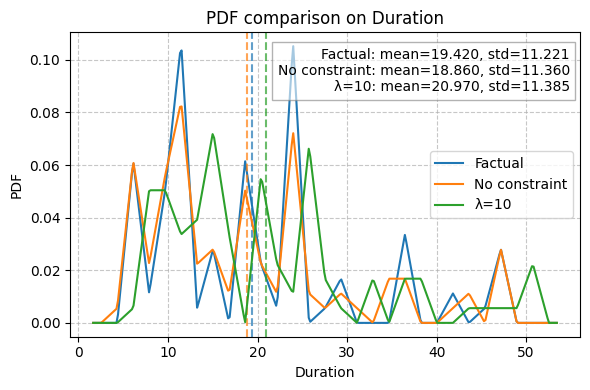

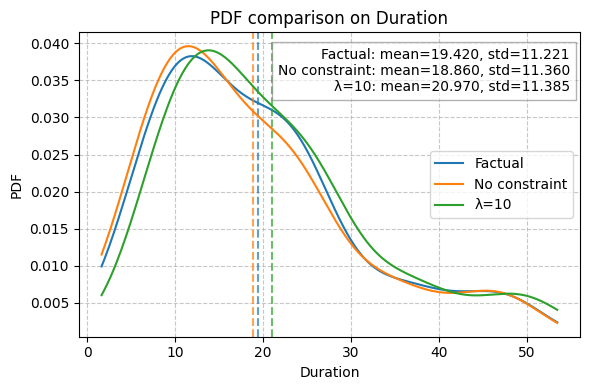

In [32]:
from utils.visualization import plot_pdf_column

# 绘制不平滑版本（直方图模式）
plot_pdf_column(
    datasets=[factual, counterfactual, best_X_raw_mean_21_100],
    column_name="Duration",
    labels=["Factual", "No constraint", "λ=10"],
    # mean=mean["Duration"],     # 保留 mean 传参，以便函数内部可标注虚线或文本
    # std=std["Duration"],       # 保留 std 参数（即使不使用，也保持接口一致）
    explain_columns=explain_columns,
    use_smoothing=False        # 🚫 不平滑（直方图模式）
)

# 绘制平滑版本（KDE模式）
plot_pdf_column(
    datasets=[factual, counterfactual, best_X_raw_mean_21_100],
    column_name="Duration",
    labels=["Factual", "No constraint", "λ=10"],
    # mean=mean["Duration"],
    # std=std["Duration"],
    explain_columns=explain_columns,
    use_smoothing=True         # ✅ 平滑（KDE模式）
)


Penalty 随迭代单调下降至近零；右轴的 Q1、Q2 同步维持在低水平（并继续下降），说明在满足约束的同时未牺牲 X 侧分布对齐（SWD）与目标对齐（WD）性能。

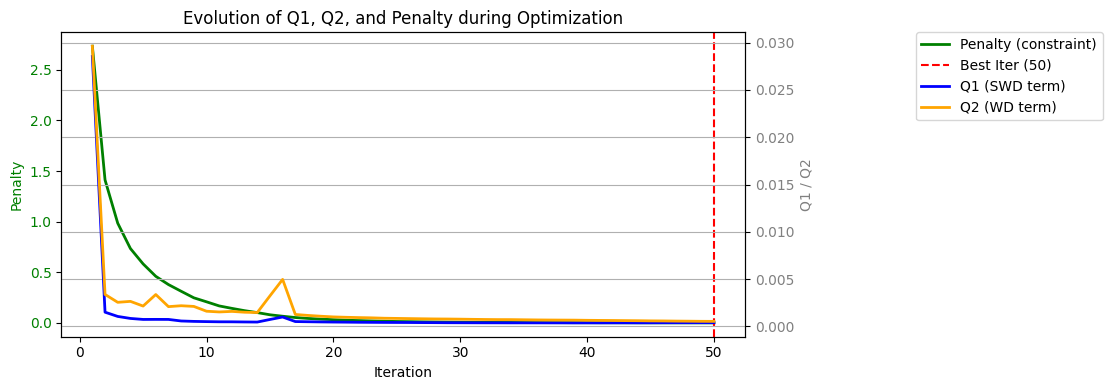

In [34]:
from importlib import reload
import explainers.dce_v2
reload(explainers.dce_v2)

from explainers.dce_v2 import DCEWithConstraints
explainer_MeanConstraint_21_100.plot_optimization_trace()

## 2.没有破坏与`X_prime`和 `y_target`的贴近性

加入均值约束后，SWD 未明显上升，说明与 `X_prime` 的贴近性未被破坏。


In [35]:
# ================== x 空间 Wasserstein ==================
set_seed(42)
dist_unc = np.sqrt(explainer.swd.distance(X_s, X_t, explainer.delta)[0].item())
print(f"SWD (unconstrained vs factual): {dist_unc:.6f}")
# ===== 有约束：X_cf vs X_fact（用同一 swd 以保持公平对比） =====
dist_con = np.sqrt(explainer.swd.distance(best_X_MeanConstraint_21_100, X_t, explainer.delta)[0].item())
print(f"SWD (constrained vs factual):   {dist_con:.6f}")

# ================== y 空间 Wasserstein ==================
y_constr = explainer_MeanConstraint_21_100.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(y, y_target, delta=delta)[0].item())
dist_y_lsc_strict = np.sqrt(explainer.wd.distance(y_constr, y_target, delta=delta)[0].item())

print(f"WD (unconstrained vs factual): {dist_y:.4f}")
print(f"WD (constrained vs factual): {dist_y_lsc_strict:.4f}")

SWD (unconstrained vs factual): 0.040687
SWD (constrained vs factual):   0.022330
WD (unconstrained vs factual): 0.2280
WD (constrained vs factual): 0.0259


加入均值约束后，y 的分布及 0.5 阈值下的 good/bad 占比与无约束情形几乎一致，说明算法在满足约束的同时保持了对 y 的匹配度

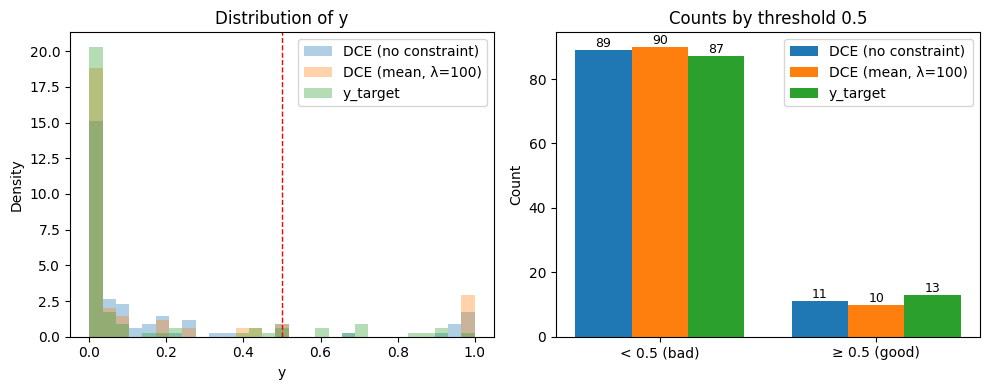

In [36]:
# ===== 取出三组 y =====
# 约束版 DCE
y_constr = explainer_MeanConstraint_21_100.best_y.squeeze().detach().cpu().numpy()

# 无约束 DCE（请替换成你自己的对象/张量）
# 例如：explainer_no_constraint.best_y 或 model(unconstrained_X)
y_unconstr = explainer.best_y.squeeze().detach().cpu().numpy()

# 目标
y_tgt = y_target.squeeze().detach().cpu().numpy()

# ===== 连续分布对比（直方图，带阈值线）=====
bins = np.linspace(0, 1, 30)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(y_unconstr, bins=bins, density=True, alpha=0.35, label="DCE (no constraint)")
axes[0].hist(y_constr,   bins=bins, density=True, alpha=0.35, label="DCE (mean, λ=100)")
axes[0].hist(y_tgt,      bins=bins, density=True, alpha=0.35, label="y_target")
axes[0].axvline(0.5, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribution of y")
axes[0].set_xlabel("y")
axes[0].set_ylabel("Density")
axes[0].legend()

# ===== 0.5 阈值下的 good/bad 柱状图 =====
thr = 0.5
def counts(arr, t=0.5):
    return int((arr < t).sum()), int((arr >= t).sum())

u_bad, u_good = counts(y_unconstr, thr)
c_bad, c_good = counts(y_constr,   thr)
t_bad, t_good = counts(y_tgt,      thr)

cats = ["< 0.5 (bad)", "≥ 0.5 (good)"]
x = np.arange(2); w = 0.26
axes[1].bar(x - w,   [u_bad, u_good], width=w, label="DCE (no constraint)")
axes[1].bar(x,       [c_bad, c_good], width=w, label="DCE (mean, λ=100)")
axes[1].bar(x + w,   [t_bad, t_good], width=w, label="y_target")

# 数值标注（可注释掉）
for i,v in enumerate([u_bad, u_good]): axes[1].text(x[i]-w, v, str(v), ha="center", va="bottom", fontsize=9)
for i,v in enumerate([c_bad, c_good]): axes[1].text(x[i],   v, str(v), ha="center", va="bottom", fontsize=9)
for i,v in enumerate([t_bad, t_good]): axes[1].text(x[i]+w, v, str(v), ha="center", va="bottom", fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(cats)
axes[1].set_title("Counts by threshold 0.5")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


## 3.回收算法有效性

目前优化是迭代了50次，均值20.9703，不满足要求，尝试均值回收算法，把均值微调到21以上。

**阈值法（θ=0.5）**：将 `y_cf` 与 `y_target` 在阈值 0.5 下标签不一致的样本标为回收候选，从这些候选中删除对均值偏移影响最大的样本；当前结果 **drop 1** 个样本即可完成修复，成功修复均值到21.104。  

In [37]:
import torch
from explainers.recovery.RecoveryManager import RecoveryManager
from explainers.recovery.Evaluator import Evaluator  

# === 1. 初始化 RecoveryManager（均值约束）===
recovery_config = [
    {"type": "mean", "bounds": {"Duration": (21, 1000)}, "priority": 0}
]
rm = RecoveryManager(feature_names=explain_columns, configs=recovery_config, verbose=True)

# === 2. 生成 R_mask（用阈值模式判断哪些需要回收）===
evaluator = Evaluator(mode="threshold", theta=0.5)   # ✅ 阈值模式
y_tgt = y_target.detach().cpu().view(-1)  
y_cf  = explainer_MeanConstraint_21_100.model(best_X_MeanConstraint_21_100).detach().cpu().view(-1)

R_mask, G_mask = evaluator.evaluate(y_target=y_tgt, y_cf=y_cf)
print(f"[threshold=0.5] 需要回收: {int(R_mask.sum())} / {R_mask.numel()}")

# === 3. 跑 Recovery（在原始量纲上执行）===
X_cf_tensor = torch.from_numpy(best_X_raw_mean_21_100[explain_columns].to_numpy()).float()
X_recovered, report = rm.run(X_cf_tensor, R_mask.bool())

# === 4. 打印被 drop 的 index ===
dropped_idx = []
for rec in rm.recoveries:   # rm.recoveries 里存的就是 (name, type, recovery_instance)
    if rec[1] == "mean":    # 找到 MeanRecovery
        mean_recovery = rec[2]
        dropped_idx = mean_recovery.last_dropped_indices
        break

if dropped_idx:
    print(f"\n被 drop 的点数: {len(dropped_idx)}")
    print("被 drop 的 index 列表:", dropped_idx)
else:
    print("\n没有 drop 点。")


[threshold=0.5] 需要回收: 23 / 100
[MeanRecovery] Duration success: mean=21.104 ∈ [21, 1000] (dropped 1)

被 drop 的点数: 1
被 drop 的 index 列表: [58]


**距离法（τ=0.05）**：对每个反事实样本y_cf，通过最优传输（OT）算法计算其与目标样本集y_target的传输矩阵，选取每行中权重最大的y_target作为匹配对象，将 `|y_cf − y_target| > 0.05` 的样本标为回收候选，从候选中删除对均值偏移贡献最大的样本。当前结果显示，仅需删除 1 个样本即可完成修复，修复后均值 21.104 满足预设要求。

In [38]:
# === 3. 用 distance 模式生成 R_mask（|y_cf - y_target| > 0.01 视为需要回收）===
evaluator = Evaluator(mode="distance", tau=0.01)   # ✅ 距离阈值
y_tgt = explainer_MeanConstraint_21_100.y_prime.detach().cpu().view(-1)  # 目标
y_cf  = explainer_MeanConstraint_21_100.model(best_X_MeanConstraint_21_100).detach().cpu().view(-1)

R_mask, G_mask = evaluator.evaluate(y_target=y_tgt, y_cf=y_cf)
print(f"[distance=0.05] 需要回收: {int(R_mask.sum())} / {R_mask.numel()}")

# === 4. 跑 Recovery（在原始量纲上执行）===
X_cf_tensor = torch.from_numpy(best_X_raw_mean_21_100[explain_columns].to_numpy()).float()
X_recovered, report = rm.run(X_cf_tensor, R_mask.bool())

# === 5. 打印被 drop 的 index ===
dropped_idx = []
for rec in rm.recoveries:   # rm.recoveries 里存的就是 (name, type, recovery_instance)
    if rec[1] == "mean":    # 找到 MeanRecovery
        mean_recovery = rec[2]
        dropped_idx = mean_recovery.last_dropped_indices
        break

if dropped_idx:
    print(f"\n被 drop 的点数: {len(dropped_idx)}")
    print("被 drop 的 index 列表:", dropped_idx)
else:
    print("\n没有 drop 点。")


[distance=0.05] 需要回收: 18 / 100
[MeanRecovery] Duration success: mean=21.104 ∈ [21, 1000] (dropped 1)

被 drop 的点数: 1
被 drop 的 index 列表: [58]


# **std**
1. 约束有效抑制波动 

2. 不破坏与 `X_prime` 和 `y_target` 的贴近性

3. 若迭代后仍超出标准差上界，可采用回收算法

## 1.约束有效压制波动
在原始 DCE 框架下，**Credit amount** 的标准差为 `2164`。若要确保反事实分布中该特征的**标准差不超过 `2000`**，可在 `dce_v2` 中通过约束管理器为 **Credit amount** 引入**标准差上界约束**。

In [21]:
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager

# ==== 把原始量纲 2000 的上界换算到归一化空间 ====
sigma_upper_raw_std_2000_100 = 2000.0
sigma_upper_norm_std_2000_100 = float(sigma_upper_raw_std_2000_100 / std["Credit amount"])  # std 为原始数据各列标准差的 Series

# 1. 约束配置：对 Credit amount 的 std 做上界约束（归一化空间）
configs_std_2000_100 = [
    {"type": "std", "bounds": {"Credit amount": sigma_upper_norm_std_2000_100}, "lambda": 100}
]

cm_credit_std_2000_100 = ConstraintManager(configs=configs_std_2000_100, feature_names=explain_columns)
set_seed(42)
# 2. 初始化 DCEWithConstraints，并绑定 manager
explainer_credit_std_2000_100 = DCEWithConstraints(
    model=model,
    df_X=df_explain,
    explain_columns=explain_columns,
    y_target=y_target,
    lr=1e-1,
    n_proj=N,
    delta=delta,
    constraint_manager=cm_credit_std_2000_100  # 直接传入
)

# 3. 执行优化
set_seed(42)
explainer_credit_std_2000_100.optimize(
    U_1=0.5,
    U_2=0.3,
    l=0.2,
    r=1,
    max_iter=50,
    tau=1e3
)

# 4. 迭代完成后提取结果
best_X_credit_std_2000_100 = explainer_credit_std_2000_100.best_X
best_y_credit_std_2000_100 = explainer_credit_std_2000_100.best_y


INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.006234373088077394
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.2777, term1=0.0289, term2=0.0299, penalty=0.24775125086307526
INFO:root:U_1-Qu_upper=0.4276851532358893, U_2-Qv_upper=0.22420781849776175
INFO:root:eta=0.7386105550346082, l=0.278, r=1
INFO:root:Iter 2: Q=0.0857, term1=0.0015, term2=0.0034, penalty=0.08277060091495514
INFO:root:U_1-Qu_upper=0.4912496274802304, U_2-Qv_upper=0.23220277241536208
INFO:root:eta=0.768263396861927, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=0.0356, term1=0.0009, term2=0.0026, penalty=0.03335387259721756
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23963510067900645
INFO:root:eta=0.7777745872189705, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=0.0173, term1=0.0007, term2=0.0023, penalty=0.015415200032293797
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.2375803474841613
INFO:root:eta=0.7901129784023411, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=0.0

In [22]:
# 简洁打印：迭代后的标准差（Credit amount，std≤2000, λ=100）
from utils.data_transform import recover_original_df, column_stats

df_norm_credit_std_2000_100, df_raw_credit_std_2000_100 = recover_original_df(
    best_X=explainer_credit_std_2000_100.best_X,
    explain_columns=explain_columns,
    mean=mean,
    std=std
)

stats_credit_std_2000_100 = column_stats(
    df_norm_credit_std_2000_100,
    df_raw_credit_std_2000_100,
    "Credit amount"
)
print(f"std (normalized) = {stats_credit_std_2000_100['std_norm']:.4f}")
print(f"std (original)   = {stats_credit_std_2000_100['std_raw']:.4f}")


[Credit amount] normalized: mean=-0.2020, std=0.6901
[Credit amount] original  : mean=2775.1203, std=2000.0195
std (normalized) = 0.6901
std (original)   = 2000.0195


In [ ]:
col = "Credit amount"
print("Factual   ddof0/1:", factual[col].std(ddof=0), factual[col].std(ddof=1))
print("CF(noc)   ddof0/1:", counterfactual[col].std(ddof=0), counterfactual[col].std(ddof=1))


对比事实、DCE反事实、带均值约束的反事实credit amount维度的分布，带std约束确实可以压制credit amount的std。迭代50轮，std从不带约束的2153到了接近2000.

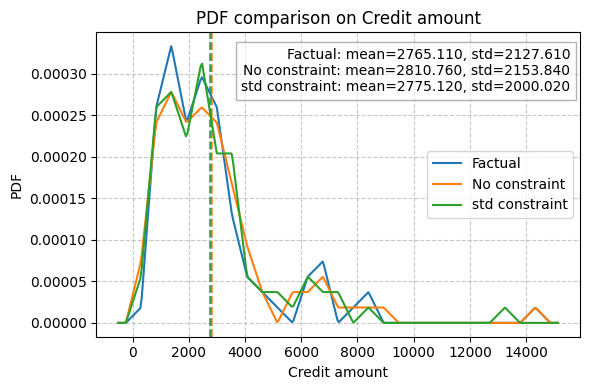

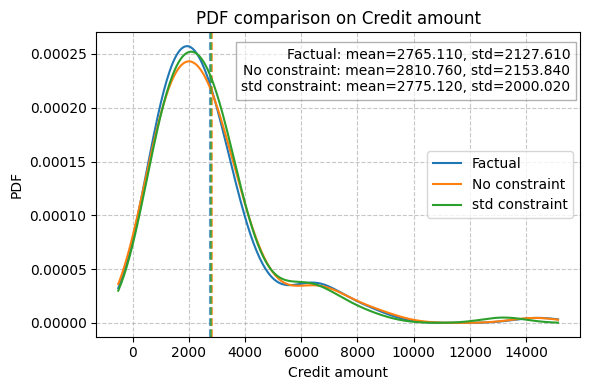

In [39]:
from utils.visualization import plot_pdf_column

# 绘制不平滑版本（直方图模式）
plot_pdf_column(
    datasets=[factual, counterfactual, df_raw_credit_std_2000_100],
    column_name="Credit amount",
    labels=["Factual", "No constraint", "std constraint"],
    # mean=mean["Credit amount"],
    # std=std["Credit amount"],
    explain_columns=explain_columns,
    use_smoothing=False  # 禁用平滑（直方图）
)

# 绘制平滑版本（KDE模式）
plot_pdf_column(
    datasets=[factual, counterfactual, df_raw_credit_std_2000_100],
    column_name="Credit amount",
    labels=["Factual", "No constraint", "std constraint"],
    # mean=mean["Credit amount"],
    # std=std["Credit amount"],
    explain_columns=explain_columns,
    use_smoothing=True  # 启用平滑（KDE）
)


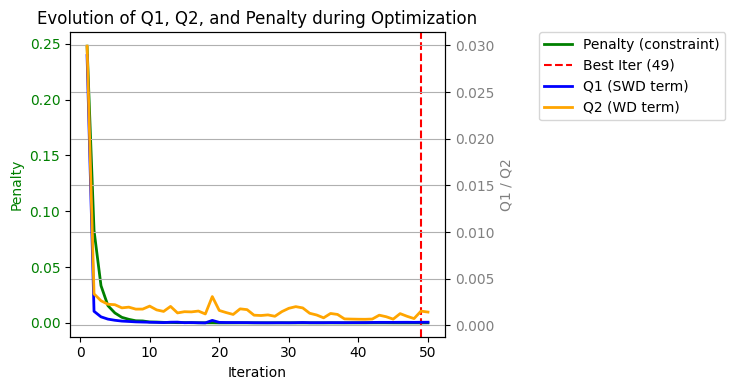

In [41]:
from importlib import reload
import explainers.dce_v2

from explainers.dce_v2 import DCEWithConstraints

# 针对 std=2000, λ=100 的实验，调用同名方法
explainer_credit_std_2000_100.plot_optimization_trace(figsize=(6, 4))

## 2.没有破坏与`X_prime`和 `y_target`的贴近性

In [42]:
# ================== x 空间 Wasserstein ==================
set_seed(42)
dist_x_unc = np.sqrt(explainer.swd.distance(X_s, X_t, explainer.delta)[0].item())
print(f"SWD (unconstrained vs factual): {dist_x_unc:.6f}")
# ===== 有约束：X_cf vs X_fact（用同一 swd 以保持公平对比） =====
dist_x_con = np.sqrt(explainer.swd.distance(best_X_credit_std_2000_100, X_t, explainer.delta)[0].item())
print(f"SWD (constrained vs factual):   {dist_x_con:.6f}")

# ================== y 空间 Wasserstein ==================
y_constr = explainer_MeanConstraint_21_100.best_y.clone().detach()

dist_y_unc = np.sqrt(explainer.wd.distance(y, y_target, delta=delta)[0].item())
dist_y_std = np.sqrt(explainer.wd.distance(y_constr, y_target, delta=delta)[0].item())

print(f"WD (unconstrained vs factual): {dist_y_unc:.4f}")
print(f"WD (constrained vs factual): {dist_y_std:.4f}")

SWD (unconstrained vs factual): 0.040687
SWD (constrained vs factual):   0.020192
WD (unconstrained vs factual): 0.2280
WD (constrained vs factual): 0.0259


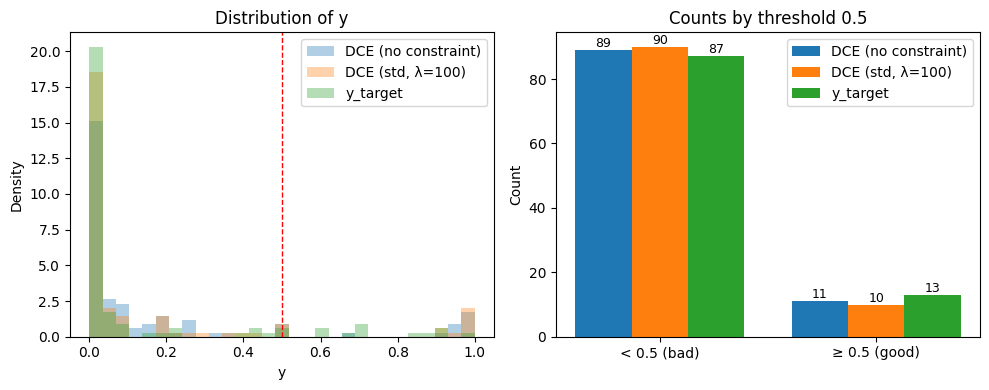

In [43]:
# ===== 取出三组 y =====
y_constr   = explainer_credit_std_2000_100.best_y.squeeze().detach().cpu().numpy()
y_unconstr = explainer.best_y.squeeze().detach().cpu().numpy()
y_tgt      = y_target.squeeze().detach().cpu().numpy()

# ===== 连续分布对比（直方图，带阈值线）=====
bins = np.linspace(0, 1, 30)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(y_unconstr, bins=bins, density=True, alpha=0.35, label="DCE (no constraint)")
axes[0].hist(y_constr,   bins=bins, density=True, alpha=0.35, label="DCE (std, λ=100)")
axes[0].hist(y_tgt,      bins=bins, density=True, alpha=0.35, label="y_target")
axes[0].axvline(0.5, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribution of y")
axes[0].set_xlabel("y")
axes[0].set_ylabel("Density")
axes[0].legend()

# ===== 0.5 阈值下的 good/bad 柱状图 =====
thr = 0.5
def counts(arr, t=0.5):
    return int((arr < t).sum()), int((arr >= t).sum())

u_bad, u_good = counts(y_unconstr, thr)
c_bad, c_good = counts(y_constr,   thr)
t_bad, t_good = counts(y_tgt,      thr)

cats = ["< 0.5 (bad)", "≥ 0.5 (good)"]
x = np.arange(2); w = 0.26
axes[1].bar(x - w, [u_bad, u_good], width=w, label="DCE (no constraint)")
axes[1].bar(x,     [c_bad, c_good], width=w, label="DCE (std, λ=100)")
axes[1].bar(x + w, [t_bad, t_good], width=w, label="y_target")

for i,v in enumerate([u_bad, u_good]): axes[1].text(x[i]-w, v, str(v), ha="center", va="bottom", fontsize=9)
for i,v in enumerate([c_bad, c_good]): axes[1].text(x[i],   v, str(v), ha="center", va="bottom", fontsize=9)
for i,v in enumerate([t_bad, t_good]): axes[1].text(x[i]+w, v, str(v), ha="center", va="bottom", fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(cats)
axes[1].set_title("Counts by threshold 0.5")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()


### 检查反事实 y 与目标 y_target 在阈值 0.5 下的标签一致性，并输出不匹配数量与混淆矩阵

In [44]:
# ===== 阈值匹配检查 =====
thr = 0.5
# 有约束
y_constr_label = (torch.tensor(y_constr) >= thr).int()
# 无约束
y_unconstr_label = (torch.tensor(y_unconstr) >= thr).int()
# 目标
y_tgt_label = (y_tgt >= thr).astype(int)

# 将 y_tgt_label 转换为 PyTorch Tensor
y_tgt_label = torch.tensor(y_tgt_label)

# 统计不匹配数量
mismatches_constr = (y_constr_label != y_tgt_label).sum().item()
mismatches_unconstr = (y_unconstr_label != y_tgt_label).sum().item()

print(f"阈值 {thr} 下：")
print(f"  DCE (constrained) vs y_target 不匹配数量: {mismatches_constr} / {len(y_tgt)}")
print(f"  DCE (no constraint) vs y_target 不匹配数量: {mismatches_unconstr} / {len(y_tgt)}")


阈值 0.5 下：
  DCE (constrained) vs y_target 不匹配数量: 23 / 100
  DCE (no constraint) vs y_target 不匹配数量: 24 / 100


In [45]:
thr = 0.5

# 转成 numpy
y_constr_np   = y_constr if isinstance(y_constr, np.ndarray) else y_constr.cpu().numpy()
y_unconstr_np = y_unconstr if isinstance(y_unconstr, np.ndarray) else y_unconstr.cpu().numpy()
y_tgt_np      = y_tgt if isinstance(y_tgt, np.ndarray) else y_tgt.cpu().numpy()

# ===== 约束版 =====
y_constr_label = (y_constr_np >= thr).astype(int)
c_bad, c_good = (y_constr_label == 0).sum(), (y_constr_label == 1).sum()
print(f"[Constrained]   bad={c_bad} ({c_bad/len(y_constr_label):.2%}), "
      f"good={c_good} ({c_good/len(y_constr_label):.2%})")

# ===== 无约束版 =====
y_unconstr_label = (y_unconstr_np >= thr).astype(int)
u_bad, u_good = (y_unconstr_label == 0).sum(), (y_unconstr_label == 1).sum()
print(f"[Unconstrained] bad={u_bad} ({u_bad/len(y_unconstr_label):.2%}), "
      f"good={u_good} ({u_good/len(y_unconstr_label):.2%})")

# ===== 目标 =====
y_tgt_label = (y_tgt_np >= thr).astype(int)
t_bad, t_good = (y_tgt_label == 0).sum(), (y_tgt_label == 1).sum()
print(f"[Target]       bad={t_bad} ({t_bad/len(y_tgt_label):.2%}), "
      f"good={t_good} ({t_good/len(y_tgt_label):.2%})")


[Constrained]   bad=90 (90.00%), good=10 (10.00%)
[Unconstrained] bad=89 (89.00%), good=11 (11.00%)
[Target]       bad=87 (87.00%), good=13 (13.00%)


In [48]:
# import numpy as np
# from sklearn.metrics import confusion_matrix

# thr = 0.5

# # 保证全部转成 numpy 数组再做 astype
# y_tgt_label      = (y_tgt.cpu().numpy()      >= thr).astype(int)
# y_constr_label   = (y_constr                 >= thr).astype(int)  # 之前已经是 numpy
# y_unconstr_label = (y_unconstr               >= thr).astype(int)

# # 混淆矩阵
# cm_constr   = confusion_matrix(y_tgt_label, y_constr_label, labels=[0,1])
# cm_unconstr = confusion_matrix(y_tgt_label, y_unconstr_label, labels=[0,1])

# print("Confusion Matrix (Constrained):")
# print(cm_constr)

# print("\nConfusion Matrix (Unconstrained):")
# print(cm_unconstr)
thr = 0.5

def to_numpy(x):
    if hasattr(x, "cpu"):      # torch.Tensor
        return x.cpu().numpy()
    elif hasattr(x, "numpy"):  # e.g. np.ndarray
        return x
    else:
        return np.array(x)

y_tgt_arr      = to_numpy(y_tgt)
y_constr_arr   = to_numpy(y_constr)
y_unconstr_arr = to_numpy(y_unconstr)

y_tgt_label      = (y_tgt_arr      >= thr).astype(int)
y_constr_label   = (y_constr_arr   >= thr).astype(int)
y_unconstr_label = (y_unconstr_arr >= thr).astype(int)

cm_constr   = confusion_matrix(y_tgt_label, y_constr_label, labels=[0,1])
cm_unconstr = confusion_matrix(y_tgt_label, y_unconstr_label, labels=[0,1])

print("Confusion Matrix (Constrained):")
print(cm_constr)

print("\nConfusion Matrix (Unconstrained):")
print(cm_unconstr)

Confusion Matrix (Constrained):
[[77 10]
 [13  0]]

Confusion Matrix (Unconstrained):
[[76 11]
 [13  0]]


## 3.回收算法有效性

目前优化是迭代了50次，std是2001.2064，不满足要求，尝试均值回收算法，把std微调到2000以下。

首先采用**阈值法（0.5）**：按 0.5 判定未逆转样本时 `R_mask` 全为 `False`，drop 2个点，修复std到1707。  

In [49]:
import torch
from explainers.recovery.RecoveryManager import RecoveryManager
from explainers.recovery.Evaluator import Evaluator

# === 1) RecoveryManager：STD 上界（原始量纲）===
recovery_config = [
    {"type": "std", "bounds": {"Credit amount": 2000.0}, "priority": 0}
]
rm = RecoveryManager(feature_names=explain_columns, configs=recovery_config, verbose=True)

# === 2) Evaluator：阈值法（theta=0.5）===
evaluator = Evaluator(mode="threshold", theta=0.5)
R_mask, G_mask = evaluator.evaluate(
    y_target=explainer_credit_std_2000_100.y_prime.detach().cpu().view(-1),
    y_cf=explainer_credit_std_2000_100.best_y.detach().cpu().view(-1)
)

# === 3) 跑 Recovery（在原始量纲上执行）===
X_cf_tensor = torch.from_numpy(df_raw_credit_std_2000_100[explain_columns].to_numpy()).float()
X_recovered, report = rm.run(X_cf_tensor, R_mask.bool())

print("Recovery report:", report)
print("修复后的 Credit amount 标准差:",
      X_recovered[:, explain_columns.index("Credit amount")].std(unbiased=False).item())

# === 4) 打印被 drop 的点的详细信息 ===
# ⚠️ 直接取 StdRecovery 里的记录
std_recovery = rm.recoveries[0][2]   # 只配置了一个 std recovery，直接拿
dropped_idx = std_recovery.last_dropped_indices

if dropped_idx:
    print(f"\n候选（R=True）数量: {int(R_mask.sum())}, 实际 drop 数量: {len(dropped_idx)}")
    y_cf = explainer_credit_std_2000_100.best_y.detach().cpu().view(-1)
    y_tgt = explainer_credit_std_2000_100.y_prime.detach().cpu().view(-1)

    for idx in dropped_idx:
        cf_val = df_raw_credit_std_2000_100.iloc[idx]["Credit amount"]
        print(f"idx={idx:3d}  CF={cf_val:.4f}  y_cf={y_cf[idx].item():.4f}  y_target={y_tgt[idx].item():.4f}")
else:
    print("\n没有 drop 点。")

[StdRecovery] Credit amount success: std=1707.715 ≤ 2000.0 (dropped 2)
Recovery report: {'Credit amount': {'std': 'success'}}
修复后的 Credit amount 标准差: 1707.7152099609375

候选（R=True）数量: 23, 实际 drop 数量: 2
idx= 26  CF=576.4630  y_cf=0.0118  y_target=0.6865
idx= 57  CF=13200.4074  y_cf=0.9996  y_target=0.0048


再采用**距离法（0.05）**：对每个反事实样本y_cf，通过最优传输（OT）算法计算其与目标样本集y_target的传输矩阵，选取每行中权重最大的y_target作为匹配对象，将 `|y_cf − y_target| > 0.05` 的样本标为回收候选。我们每次从备选集合中找到最大和最小的两个值同时删除，这样有效抵消单侧删除带来的均值偏移，从而在降低标准差的同时保持总体均值稳定。

In [50]:
# # ===  用 distance 模式生成 R_mask（|y_cf - y_target| > 0.05 需要回收）===
evaluator = Evaluator(mode="distance", tau=0.01)
y_tgt = explainer_credit_std_2000_100.y_prime.detach().cpu().view(-1)  # 目标
y_cf  = explainer_credit_std_2000_100.model(
            explainer_credit_std_2000_100.best_X
        ).detach().cpu().view(-1)  # 反事实预测

R_mask, G_mask = evaluator.evaluate(y_target=y_tgt, y_cf=y_cf)
# print(f"[distance=0.05] 需要回收: {int(R_mask.sum())} / {R_mask.numel()}")

# === 4. 跑 Recovery（在原始量纲上；DataFrame -> Tensor）===
X_cf_tensor = torch.from_numpy(df_raw_credit_std_2000_100[explain_columns].to_numpy()).float()
X_recovered, report = rm.run(X_cf_tensor, R_mask.bool())

print("Recovery report:", report)
print("修复后的 Credit amount 标准差:",
      X_recovered[:, explain_columns.index("Credit amount")].std(unbiased=False).item())

# === 5. 打印被 drop 的点的详细信息 ===
# ⚠️ 直接拿 rm.recoveries[0][2] 就是 StdRecovery
std_recovery = rm.recoveries[0][2]
dropped_idx = std_recovery.last_dropped_indices

if dropped_idx:
    print(f"\n候选（R=True）数量: {int(R_mask.sum())}, 实际 drop 数量: {len(dropped_idx)}")
    for idx in dropped_idx:
        cf_val = df_raw_credit_std_2000_100.iloc[idx]["Credit amount"]
        fa_val = factual.iloc[idx]["Credit amount"] if "factual" in locals() else float("nan")
        print(f"idx={idx:3d}  CF={cf_val:.4f}  FA={fa_val:.4f}  "
              f"y_cf={y_cf[idx].item():.4f}  y_target={y_tgt[idx].item():.4f}")
else:
    print("\n没有 drop 点。")


[StdRecovery] Credit amount success: std=1977.401 ≤ 2000.0 (dropped 2)
Recovery report: {'Credit amount': {'std': 'success'}}
修复后的 Credit amount 标准差: 1977.4013671875

候选（R=True）数量: 18, 实际 drop 数量: 2
idx= 40  CF=758.0365  FA=727.0000  y_cf=0.9748  y_target=0.0009
idx= 82  CF=6342.0921  FA=6872.0000  y_cf=0.9659  y_target=0.0000


# **LSC**

原始 DCE 优化目标只关注 OT 距离 (X, y 分布)，没有额外约束 Credit~Duration 的结构性。👉 LSCConstraint ——它的作用就是在优化时“拉住”这种线性结构，让生成的 counterfactuals 不仅分布合理，还要遵守这种业务逻辑上的依赖。我们提供 两种模式（hinge 与 strict）以适应不同业务场景对约束强度的需求。

## 在训练集上拟合duration和credit amount的关系

在归一化空间下，我们在训练集（800 条）上拟合得到的关系为 **Duration ≈ 0.63 × Credit amount**，其 MSE≈0.6，说明两者存在一定的线性结构；因此在这两个变量上探索结构约束是合理的。（若 MSE 接近 1，则表明在归一化空间下两变量几乎不存在可解释的线性关系）。先画图展示训练集（800 条）、解释集事实样本（100 条）和原始 DCE 反事实（100 条）在 Credit 与 Duration 之间的线性关系对比。

Linear model: Duration = 0.6264 * Credit amount + 0.0000
MSE on training data: 0.6069
MSE on df_explain data: 0.5883
MSE on X_s (counterfactuals): 0.6166


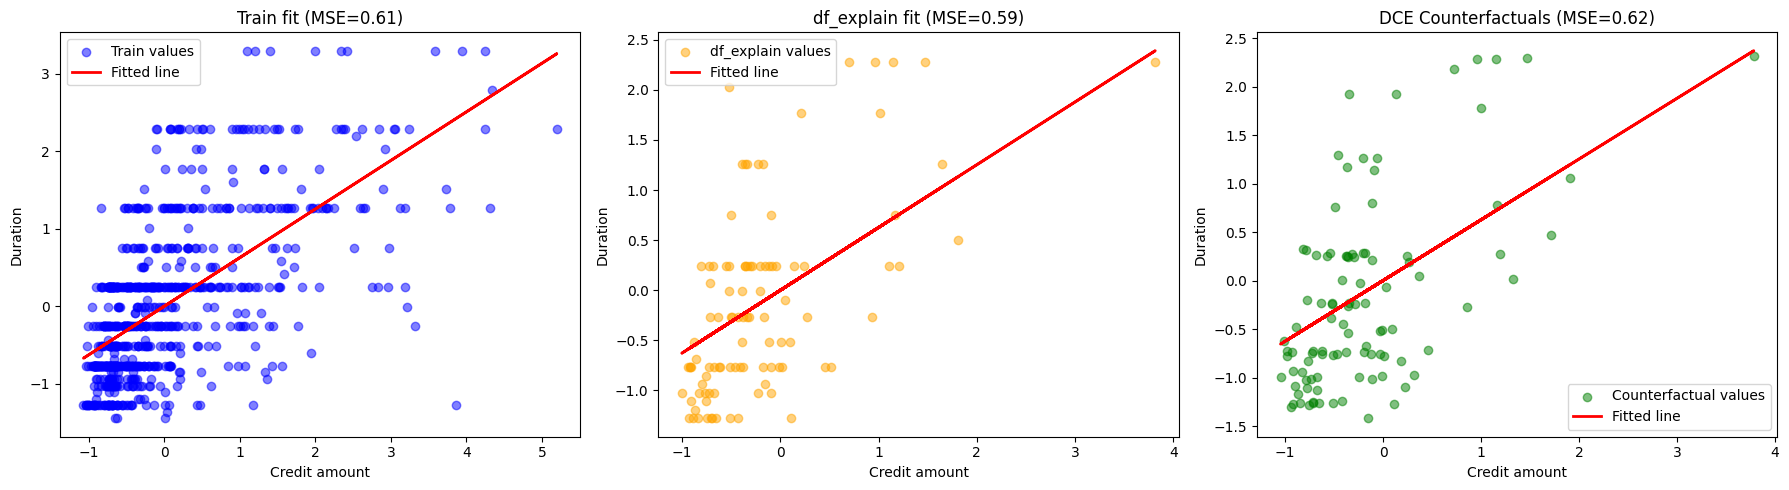

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Step 1. 在训练集拟合线性模型: Credit amount → Duration
X_lin_train = X_train[["Credit amount"]].values.reshape(-1, 1)
y_lin_train = X_train["Duration"].values

lin_reg = LinearRegression()
lin_reg.fit(X_lin_train, y_lin_train)

y_pred_train = lin_reg.predict(X_lin_train)
mse_train = mean_squared_error(y_lin_train, y_pred_train)

coef = lin_reg.coef_[0]
intercept = lin_reg.intercept_
print(f"Linear model: Duration = {coef:.4f} * Credit amount + {intercept:.4f}")
print(f"MSE on training data: {mse_train:.4f}")

# Step 2. 在 df_explain 上评估
X_lin_explain = df_explain[["Credit amount"]].values.reshape(-1, 1)
y_lin_explain = df_explain["Duration"].values
y_pred_explain = lin_reg.predict(X_lin_explain)
mse_explain = mean_squared_error(y_lin_explain, y_pred_explain)
print(f"MSE on df_explain data: {mse_explain:.4f}")

# Step 3. 在 DCE 生成的 X_s 上评估
idx_credit = explain_columns.index("Credit amount")
idx_duration = explain_columns.index("Duration")

X_s_credit = X_s[:, idx_credit].detach().cpu().numpy().reshape(-1, 1)
y_s_true_duration = X_s[:, idx_duration].detach().cpu().numpy()
y_s_pred_duration = lin_reg.predict(X_s_credit)
mse_s = mean_squared_error(y_s_true_duration, y_s_pred_duration)
print(f"MSE on X_s (counterfactuals): {mse_s:.4f}")

# Step 4. 三个图并排比较
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 左图：训练集
axes[0].scatter(X_lin_train, y_lin_train, color="blue", alpha=0.5, label="Train values")
axes[0].plot(X_lin_train, y_pred_train, color="red", linewidth=2, label="Fitted line")
axes[0].set_xlabel("Credit amount")
axes[0].set_ylabel("Duration")
axes[0].set_title(f"Train fit (MSE={mse_train:.2f})")
axes[0].legend()

# 中图：df_explain
axes[1].scatter(X_lin_explain, y_lin_explain, color="orange", alpha=0.5, label="df_explain values")
axes[1].plot(X_lin_explain, y_pred_explain, color="red", linewidth=2, label="Fitted line")
axes[1].set_xlabel("Credit amount")
axes[1].set_ylabel("Duration")
axes[1].set_title(f"df_explain fit (MSE={mse_explain:.2f})")
axes[1].legend()

# 右图：DCE生成的反事实样本
axes[2].scatter(X_s_credit, y_s_true_duration, color="green", alpha=0.5, label="Counterfactual values")
axes[2].plot(X_s_credit, y_s_pred_duration, color="red", linewidth=2, label="Fitted line")
axes[2].set_xlabel("Credit amount")
axes[2].set_ylabel("Duration")
axes[2].set_title(f"DCE Counterfactuals (MSE={mse_s:.2f})")
axes[2].legend()

plt.tight_layout()
plt.show()

## 🌿 模式一：hinge 模式 
不试图“绝对拟合线性结构”,只温和压制明显偏离结构的点，保留数据本身的波动性。我们将训练集上 **Credit → Duration** 拟合得到的 **MSE（≈0.6）** 作为 hinge 的容忍阈值。

In [49]:
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager

# ================== 1. 定义 LSC (hinge) 约束 ==================
configs_hinge = [
    {
        "type": "lsc",
        "relation": {
            "Duration": (["Credit amount"], [0.6264], 0.0)
        },
        "lambda": 10,
        "mode": "hinge",
        "tolerance": mse_train   # 🚩 直接用第一段算好的 training MSE
    }
]

# 🚩 保证顺序和 df_explain.columns 一致
feature_names = list(df_explain.columns)
constraint_manager_hinge = ConstraintManager(configs=configs_hinge, feature_names=feature_names)

# ================== 2. 初始化 Explainer ==================
set_seed(42)
explainer_lsc_hinge = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta,
    constraint_manager=constraint_manager_hinge
)

# ================== 3. 优化生成 counterfactuals ==================
set_seed(42)
explainer_lsc_hinge.optimize(
    U_1=0.5, 
    U_2=0.3, 
    l=0.2, 
    r=1, 
    max_iter=50, 
    tau=10
)

X_s_lsc_hinge = explainer_lsc_hinge.best_X[:, explainer_lsc_hinge.explain_indices].clone().detach()
print("✅ Generated CFs with LSC (hinge). Shape:", X_s_lsc_hinge.shape)

# ================== 4. 用 cell1 的 lin_reg 评估 LSC (hinge) ==================
idx_credit = explain_columns.index("Credit amount")
idx_duration = explain_columns.index("Duration")

X_s_credit_lsc_hinge = X_s_lsc_hinge[:, idx_credit].cpu().numpy().reshape(-1, 1)
y_s_true_duration_lsc_hinge = X_s_lsc_hinge[:, idx_duration].cpu().numpy()
y_s_pred_duration_lsc_hinge = lin_reg.predict(X_s_credit_lsc_hinge)
mse_s_lsc_hinge = mean_squared_error(y_s_true_duration_lsc_hinge, y_s_pred_duration_lsc_hinge)

print(f"MSE on X_s (DCE no constraint): {mse_s:.4f}")       # 🚩 来自 cell1
print(f"MSE on X_s_lsc (hinge):        {mse_s_lsc_hinge:.4f}")

# # ================== 5. 也可以调用 LSC 自带的 MSE 计算（和手算对比用） ==================
# # 直接用 constraint_manager 里的约束对象
# lsc_module = constraint_manager_hinge.constraints[0]  # 取第一个 LSC 约束

# # 对带 hinge 的反事实样本计算 MSE
# mse_dict_lsc_hinge = lsc_module.compute_mse(X_s_lsc_hinge)
# print("MSE dict from LSC module (hinge):", mse_dict_lsc_hinge)

# # 对无约束的反事实样本计算 MSE
# mse_dict_no_constr = lsc_module.compute_mse(X_s)
# print("MSE dict from LSC module (no constraint):", mse_dict_no_constr)

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.006234373088077394
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=2.6040, term1=0.0001, term2=0.0380, penalty=2.5659236907958984
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.01446953597567846
INFO:root:eta=0.9786248814117625, l=0.278, r=1
INFO:root:Iter 2: Q=2.3691, term1=0.0001, term2=0.0348, penalty=2.3350837230682373
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.028110740545025714
INFO:root:eta=0.9615687523178139, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=2.1592, term1=0.0002, term2=0.0322, penalty=2.128279685974121
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.036548517199909925
INFO:root:eta=0.9532779848535523, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=1.9700, term1=0.0002, term2=0.0298, penalty=1.9415885210037231
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.05093858447484495
INFO:root:eta=0.9397540174675372, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=1.7960, term1=0.0002, term2=0.0279,

✅ Generated CFs with LSC (hinge). Shape: torch.Size([100, 9])
MSE on X_s (DCE no constraint): 0.6166
MSE on X_s_lsc (hinge):        0.3045


与原始 DCE 相比，引入 LSC（hinge）后生成样本的 MSE 显著降低(0.6->0.3)，说明反事实更好地遵循了 Credit–Duration 的线性结构约束。

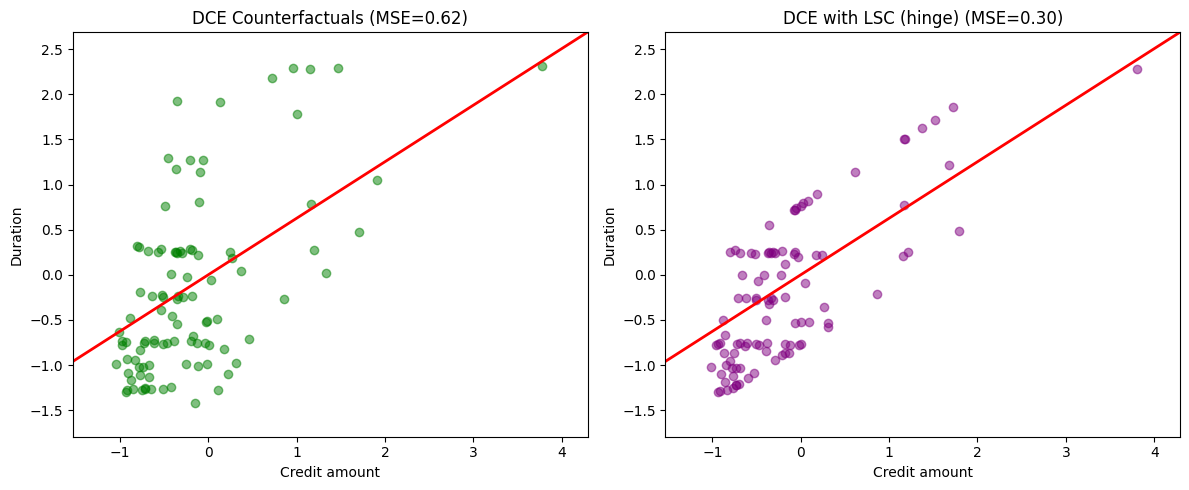

In [50]:
# ================== 5. 画对比图 ==================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 统一横纵轴范围
x_min = min(X_s_credit.min(), X_s_credit_lsc_hinge.min())
x_max = max(X_s_credit.max(), X_s_credit_lsc_hinge.max())
y_min = min(y_s_true_duration.min(), y_s_true_duration_lsc_hinge.min())
y_max = max(y_s_true_duration.max(), y_s_true_duration_lsc_hinge.max())

x_buffer = 0.1 * (x_max - x_min)
y_buffer = 0.1 * (y_max - y_min)

x_min, x_max = x_min - x_buffer, x_max + x_buffer
y_min, y_max = y_min - y_buffer, y_max + y_buffer

# ===== 拟合线覆盖整个 x 范围 =====
x_line = np.linspace(x_min, x_max, 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

# 左图：DCE 无约束
axes[0].scatter(X_s_credit, y_s_true_duration, color="green", alpha=0.5)
axes[0].plot(x_line, y_line, color="red", linewidth=2)   # 🚩baseline回归线
axes[0].set_xlabel("Credit amount")
axes[0].set_ylabel("Duration")
axes[0].set_title(f"DCE Counterfactuals (MSE={mse_s:.2f})")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

# 右图：DCE + LSC (hinge)
axes[1].scatter(X_s_credit_lsc_hinge, y_s_true_duration_lsc_hinge, color="purple", alpha=0.5)
axes[1].plot(x_line, y_line, color="red", linewidth=2)   # 🚩baseline回归线
axes[1].set_xlabel("Credit amount")
axes[1].set_ylabel("Duration")
axes[1].set_title(f"DCE with LSC (hinge) (MSE={mse_s_lsc_hinge:.2f})")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

检查 Wasserstein 距离:为了确认在提升线性结构一致性的同时，反事实分布仍贴近事实分布，未出现明显偏离。

In [51]:
# ================== X 空间 Wasserstein ==================
dist_X = np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())
dist_X_lsc_hinge = np.sqrt(explainer.swd.distance(X_s_lsc_hinge, X_t, delta)[0].item())

print(f"Wasserstein distance (X, 原始DCE vs 事实): {dist_X:.4f}")
print(f"Wasserstein distance (X, LSC-hinge-DCE vs 事实): {dist_X_lsc_hinge:.4f}")

# ================== y 空间 Wasserstein ==================
y_lsc_hinge = explainer_lsc_hinge.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(y, y_target, delta=delta)[0].item())
dist_y_lsc_hinge = np.sqrt(explainer.wd.distance(y_lsc_hinge, y_target, delta=delta)[0].item())

print(f"Wasserstein distance (y, 原始DCE vs 事实): {dist_y:.4f}")
print(f"Wasserstein distance (y, LSC-hinge-DCE vs 事实): {dist_y_lsc_hinge:.4f}")

Wasserstein distance (X, 原始DCE vs 事实): 0.0407
Wasserstein distance (X, LSC-hinge-DCE vs 事实): 0.0359
Wasserstein distance (y, 原始DCE vs 事实): 0.2280
Wasserstein distance (y, LSC-hinge-DCE vs 事实): 0.1111


## 🌿 模式二：strict 模式
模拟严格线性结构场景，确保反事实严格遵循预设的因果关系。⚠️ 注意提醒：若结构关系本身就是噪声较大的伪线性，strict 可能会“过拟合结构”

In [52]:
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager

# ================== 1. 定义约束 ==================
configs = [
    {
        "type": "lsc",
        "relation": {
            # Duration ≈ 0.6264 * Credit amount + 0.0
            "Duration": (["Credit amount"], [0.6264], 0.0)
        },
        "lambda": 10,
        "mode": "strict"
    }
]

# 🚩 传入全局列名顺序，保证和 df_explain.columns 一致
feature_names = list(df_explain.columns)
constraint_manager = ConstraintManager(configs=configs, feature_names=feature_names)

# print("Explain columns:", explain_columns)
# print("All feature names:", feature_names)

# ================== 2. 初始化 Explainer ==================
set_seed(42)
explainer_lsc_strict = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta,
    constraint_manager=constraint_manager
)

# ================== 3. 优化生成 counterfactuals ==================
set_seed(42)
explainer_lsc_strict.optimize(     # 🚩 用老师的 optimize
    U_1=0.5, 
    U_2=0.3, 
    l=0.2, 
    r=1, 
    max_iter=50, 
    tau=10
)

X_s_lsc_strict = explainer_lsc_strict.best_X[:, explainer_lsc_strict.explain_indices].clone().detach()
# print("✅ Generated CFs with LSC. Shape:", X_s_lsc.shape)

# ================== 4. 用 cell1 的 lin_reg 评估 LSC CF ==================
idx_credit = explain_columns.index("Credit amount")
idx_duration = explain_columns.index("Duration")

X_s_credit_lsc_strict = X_s_lsc_strict[:, idx_credit].cpu().numpy().reshape(-1, 1)
y_s_true_duration_lsc_strict = X_s_lsc_strict[:, idx_duration].cpu().numpy()
y_s_pred_duration_lsc_strict = lin_reg.predict(X_s_credit_lsc_strict)
mse_s_lsc_strict = mean_squared_error(y_s_true_duration_lsc_strict, y_s_pred_duration_lsc_strict)

print(f"MSE on X_s (DCE no constraint): {mse_s:.4f}")       # cell1 里算过的
print(f"MSE on X_s_lsc (DCE with LSC): {mse_s_lsc_strict:.4f}")

# # ================== 5. 也可以调用 LSC 自带的 MSE 计算（和手算对比用） ==================
# # 直接用 constraint_manager 里的约束对象
# lsc_module_strict = constraint_manager.constraints[0]  # 取第一个 LSC 约束

# # 对 strict 反事实样本计算 MSE
# mse_dict_lsc_strict = lsc_module_strict.compute_mse(X_s_lsc_strict)
# print("MSE dict from LSC module (strict):", mse_dict_lsc_strict)

# # 对无约束的反事实样本计算 MSE
# mse_dict_no_constr = lsc_module_strict.compute_mse(X_s)
# print("MSE dict from LSC module (no constraint):", mse_dict_no_constr)

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.006234373088077394
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=5.6191, term1=0.0001, term2=0.0379, penalty=5.581171989440918
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.014834275141795916
INFO:root:eta=0.9781015956937603, l=0.278, r=1
INFO:root:Iter 2: Q=5.3076, term1=0.0001, term2=0.0347, penalty=5.273714542388916
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.028590290042083855
INFO:root:eta=0.9609486027283228, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=5.0146, term1=0.0002, term2=0.0321, penalty=4.983755111694336
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.037097056983524446
INFO:root:eta=0.952625189331879, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=4.7387, term1=0.0003, term2=0.0300, penalty=4.710145473480225
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.0498005005251021
INFO:root:eta=0.9409781273140592, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=4.4786, term1=0.0003, term2=0.0282, pen

MSE on X_s (DCE no constraint): 0.6166
MSE on X_s_lsc (DCE with LSC): 0.0378


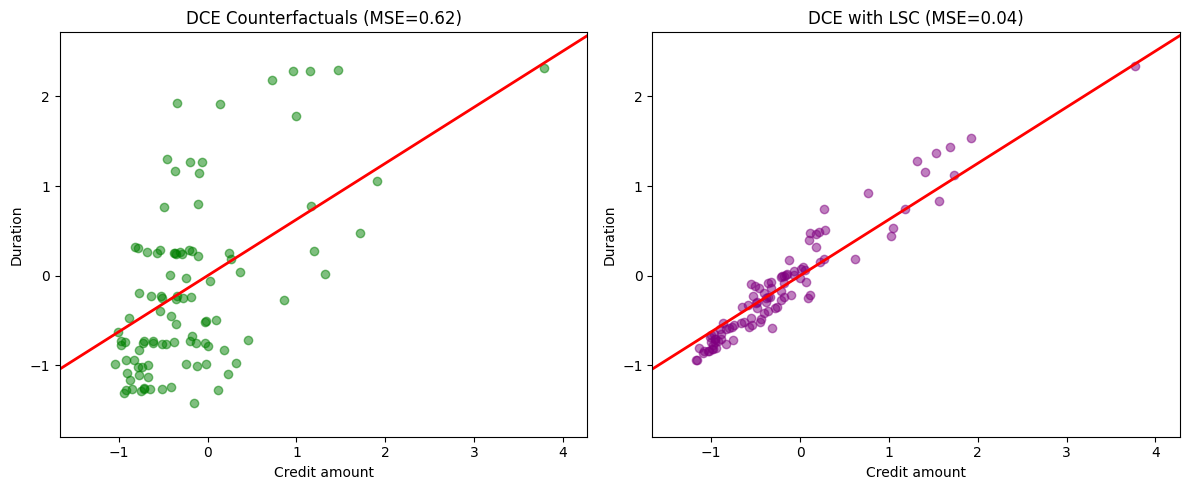

In [53]:
# ================== 5. 画对比图 ==================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 统一横纵轴范围
x_min = min(X_s_credit.min(), X_s_credit_lsc_strict.min())
x_max = max(X_s_credit.max(), X_s_credit_lsc_strict.max())
y_min = min(y_s_true_duration.min(), y_s_true_duration_lsc_strict.min())
y_max = max(y_s_true_duration.max(), y_s_true_duration_lsc_strict.max())

x_buffer = 0.1 * (x_max - x_min)
y_buffer = 0.1 * (y_max - y_min)

x_min, x_max = x_min - x_buffer, x_max + x_buffer
y_min, y_max = y_min - y_buffer, y_max + y_buffer

# ===== 拟合线覆盖整个 x 范围 =====
x_line = np.linspace(x_min, x_max, 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

# 左图：DCE 无约束
axes[0].scatter(X_s_credit, y_s_true_duration, color="green", alpha=0.5)
axes[0].plot(x_line, y_line, color="red", linewidth=2)   # 🚩用全范围的线
axes[0].set_xlabel("Credit amount")
axes[0].set_ylabel("Duration")
axes[0].set_title(f"DCE Counterfactuals (MSE={mse_s:.2f})")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

# 右图：DCE + LSC
axes[1].scatter(X_s_credit_lsc_strict, y_s_true_duration_lsc_strict, color="purple", alpha=0.5)
axes[1].plot(x_line, y_line, color="red", linewidth=2)   # 🚩同一条回归线
axes[1].set_xlabel("Credit amount")
axes[1].set_ylabel("Duration")
axes[1].set_title(f"DCE with LSC (MSE={mse_s_lsc_strict:.2f})")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


strict 模式虽然直接把MSE降低到0.04，但也带来了分布距离的上升，说明其过度强调线性结构，可能破坏生成样本与事实分布的贴近性，因此在实际应用中需谨慎使用。

In [54]:
# ================== X 空间 Wasserstein ==================
dist_X = np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())
dist_X_lsc_strict = np.sqrt(explainer.swd.distance(X_s_lsc_strict, X_t, delta)[0].item())

print(f"Wasserstein distance (X, 原始DCE vs 事实): {dist_X:.4f}")
print(f"Wasserstein distance (X, LSC-strict-DCE vs 事实): {dist_X_lsc_strict:.4f}")

# ================== y 空间 Wasserstein ==================
y_lsc_strict = explainer_lsc_strict.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(y, y_target, delta=delta)[0].item())
dist_y_lsc_strict = np.sqrt(explainer.wd.distance(y_lsc_strict, y_target, delta=delta)[0].item())

print(f"Wasserstein distance (y, 原始DCE vs 事实): {dist_y:.4f}")
print(f"Wasserstein distance (y, LSC-strict-DCE vs 事实): {dist_y_lsc_strict:.4f}")

Wasserstein distance (X, 原始DCE vs 事实): 0.0407
Wasserstein distance (X, LSC-strict-DCE vs 事实): 0.0550
Wasserstein distance (y, 原始DCE vs 事实): 0.2280
Wasserstein distance (y, LSC-strict-DCE vs 事实): 0.1200


## 🌿 对比strict和hinge对反事实均值的附带效果

Strict LSC 在均值上保持了与事实分布的高度一致性，而 Hinge LSC 更宽松，导致均值出现一定偏移。

均值贴近事实分布是 LSC 的一个附带效果。Strict 更倾向于让均值保持一致（好处是分布稳定，坏处是可能过度收紧），而 Hinge 更宽松，允许均值有偏移（好处是多样性更强，坏处是与事实分布差距更大）。

In [55]:
import numpy as np

# 验证是否逐元素相等
equal_credit = np.allclose(X_s_credit_lsc_hinge, X_s_credit_lsc_strict, atol=1e-8)
equal_duration = np.allclose(y_s_true_duration_lsc_hinge, y_s_true_duration_lsc_strict, atol=1e-8)

# print("Credit 列是否完全一致:", equal_credit)
# print("Duration 列是否完全一致:", equal_duration)

# 打印均值对比
print("\n--- 均值对比 ---")
print(f"Credit (Factual)    mean: {df_explain['Credit amount'].mean():.6f}")
print(f"Credit (Strict LSC) mean: {X_s_credit_lsc_strict.mean():.6f}")
print(f"Credit (Hinge LSC)  mean: {X_s_credit_lsc_hinge.mean():.6f}")

print(f"Duration (Factual)    mean: {df_explain['Duration'].mean():.6f}")
print(f"Duration (Strict LSC) mean: {y_s_true_duration_lsc_strict.mean():.6f}")
print(f"Duration (Hinge LSC)  mean: {y_s_true_duration_lsc_hinge.mean():.6f}")


--- 均值对比 ---
Credit (Factual)    mean: -0.205477
Credit (Strict LSC) mean: -0.210649
Credit (Hinge LSC)  mean: -0.170627
Duration (Factual)    mean: -0.141862
Duration (Strict LSC) mean: -0.140832
Duration (Hinge LSC)  mean: -0.203859


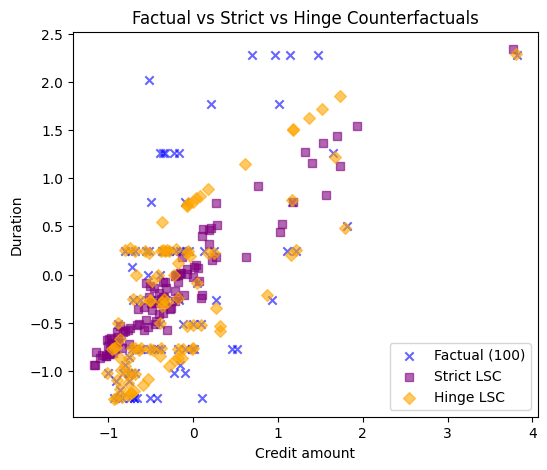

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

# 原始解释集事实样本 (100 条) —— 用叉叉
plt.scatter(df_explain["Credit amount"], df_explain["Duration"], 
            color="blue", alpha=0.6, label="Factual (100)", marker="x")

# Strict LSC 生成的反事实 —— 方块
plt.scatter(X_s_credit_lsc_strict, y_s_true_duration_lsc_strict, 
            color="purple", alpha=0.6, label="Strict LSC", marker="s")

# Hinge LSC 生成的反事实 —— 菱形
plt.scatter(X_s_credit_lsc_hinge, y_s_true_duration_lsc_hinge, 
            color="orange", alpha=0.6, label="Hinge LSC", marker="D")

plt.xlabel("Credit amount")
plt.ylabel("Duration")
plt.title("Factual vs Strict vs Hinge Counterfactuals")
plt.legend()
plt.show()


# **FSD**

👉 FSDConstraint —— 它的作用是在因果逻辑下，从 y 的改善反推 x 必须整体沿单一方向移动（如 Good 比例提升 → Duration 整体左移），确保反事实分布在每个概率点都优于事实分布，不能出现任何违背业务逻辑的反向情况。

❌ 未加 FSD 约束：是否满足一阶随机占优(FSD): False
❌ 未加 FSD 约束：违反点数量: 51
❌ 未加 FSD 约束：区间满足比例: 0.8738538


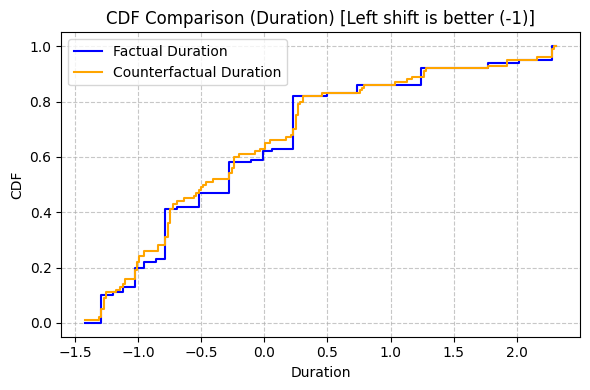

In [51]:
from explainers.constraints.FSDConstraint import FSDConstraintTorch

# ================== Duration 分布对比（未加 FSD 约束） ==================
idx_duration = explain_columns.index("Duration")

fact_duration = X_t[:, idx_duration].cpu().numpy()
cf_duration   = X_s[:, idx_duration].cpu().numpy()

# 统一用新版接口
result_cf = FSDConstraintTorch.check_FSD(
    fact_duration, cf_duration,
    direction=-1   # 🚩 Duration 越小越优
)

print("❌ 未加 FSD 约束：是否满足一阶随机占优(FSD):", result_cf["holds"])
print("❌ 未加 FSD 约束：违反点数量:", len(result_cf["violations"]))
# print("❌ 未加 FSD 约束：点满足比例:", result_cf["point_ratio"])
print("❌ 未加 FSD 约束：区间满足比例:", result_cf["interval_ratio"])

# ================== 画CDF对比 ==================
FSDConstraintTorch.plot_cdf(
    fact=fact_duration,
    cf=cf_duration,
    feature_name="Duration",
    direction=-1
)

无论从满足点的比例还是区间的比例来看，加入 FSD 约束后的反事实分布整体更符合我们期望的左移趋势。

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.006234373088077394
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=2.3452, term1=0.0290, term2=0.0298, penalty=2.3153321743011475
INFO:root:U_1-Qu_upper=0.4272551384457907, U_2-Qv_upper=0.22392940839770126
INFO:root:eta=0.7386511224702693, l=0.278, r=1
INFO:root:Iter 2: Q=6.8039, term1=0.0015, term2=0.0034, penalty=6.801055908203125
INFO:root:U_1-Qu_upper=0.4874887289676461, U_2-Qv_upper=0.23165064293322998
INFO:root:eta=0.7674278857021813, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=6.8840, term1=0.0009, term2=0.0027, penalty=6.881713390350342
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23933555712799182
INFO:root:eta=0.7779624460755232, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=6.9097, term1=0.0007, term2=0.0024, penalty=6.907702922821045
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.2365524033465103
INFO:root:eta=0.790729446971761, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=6.7728, ter

✅ 带 FSD 约束：是否满足一阶随机占优(FSD): False
✅ 带 FSD 约束：违反点数量: 19
✅ 带 FSD 约束：区间满足比例: 0.9560926596275588
事实分布 Duration 均值: -0.14186245699864822
FSD 约束反事实 Duration 均值: -0.39716724


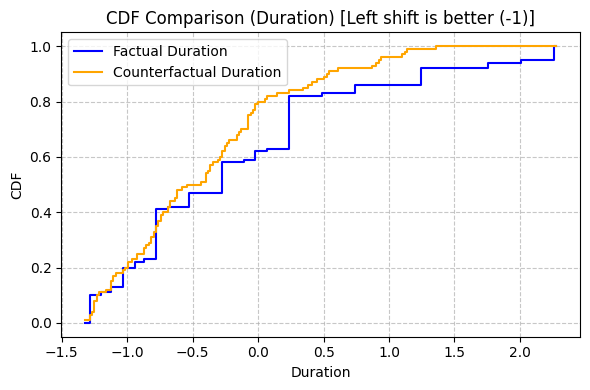

In [52]:
import numpy as np
import torch
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager
from explainers.constraints.FSDConstraint import FSDConstraintTorch

# ================== 1. 定义 FSD 约束（Duration 左移更优） ==================
configs = [
    {
        "type": "fsd",
        "lambda": 1,   # 
        "dir_map": {"Duration": -1},   # 🚩 Duration 必须左移
        "M": 100,         # 采样 50 个 factual 点
        "sample_mode": "quantile"
    }
]

feature_names = list(df_explain.columns)
constraint_manager = ConstraintManager(configs=configs, feature_names=feature_names)

# ================== 2. 初始化带约束的 DCE ==================
set_seed(42)
explainer_fsd = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta,
    constraint_manager=constraint_manager
)

# ================== 3. 优化生成反事实 ==================
set_seed(42)
explainer_fsd.optimize(U_1=0.5, U_2=0.3, l=0.2, r=1, max_iter=50, tau=1e3)

X_s_fsd = explainer_fsd.best_X[:, explainer_fsd.explain_indices].clone().detach()

# ================== 4. 检查 FSD 条件 ==================
idx_duration = explain_columns.index("Duration")

fact_duration = df_explain.iloc[:, idx_duration].values
cf_duration_fsd = X_s_fsd[:, idx_duration].cpu().numpy()

result_fsd = FSDConstraintTorch.check_FSD(
    fact_duration, cf_duration_fsd,
    direction=-1   # 🚩 Duration 左移更优
)

print("✅ 带 FSD 约束：是否满足一阶随机占优(FSD):", result_fsd["holds"])
print("✅ 带 FSD 约束：违反点数量:", len(result_fsd["violations"]))
# print("✅ 带 FSD 约束：点满足比例:", result_fsd["point_ratio"])
print("✅ 带 FSD 约束：区间满足比例:", result_fsd["interval_ratio"])
print("事实分布 Duration 均值:", np.mean(fact_duration))
print("FSD 约束反事实 Duration 均值:", np.mean(cf_duration_fsd))

# ================== 5. 画CDF对比 ==================
FSDConstraintTorch.plot_cdf(
    fact=fact_duration,
    cf=cf_duration_fsd,
    feature_name="Duration",
    direction=-1
)

看PDF：加入 FSD 约束后，Duration 分布整体左移

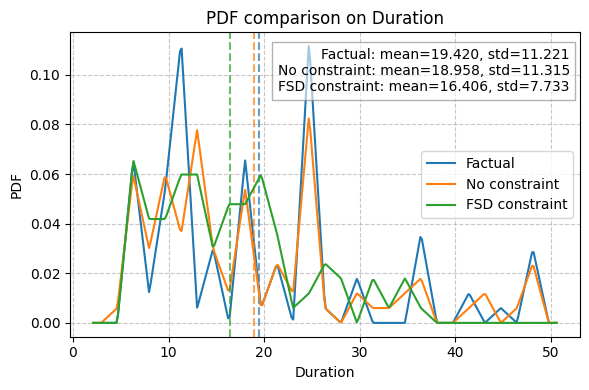

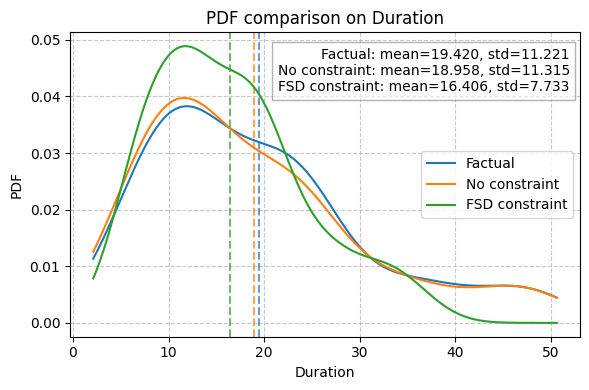

In [53]:
from utils.visualization import plot_pdf_column

# 绘制不平滑版本（直方图模式）
plot_pdf_column(
    datasets=[df_explain, X_s, X_s_fsd],
    column_name="Duration",
    labels=["Factual", "No constraint", "FSD constraint"],
    mean=mean["Duration"],
    std=std["Duration"],
    explain_columns=explain_columns,
    use_smoothing=False  # 禁用平滑（默认值，可省略）
)

# 绘制平滑版本（KDE模式）
plot_pdf_column(
    datasets=[df_explain, X_s, X_s_fsd],
    column_name="Duration",
    labels=["Factual", "No constraint", "FSD constraint"],
    mean=mean["Duration"],
    std=std["Duration"],
    explain_columns=explain_columns,
    use_smoothing=True  # 启用平滑
)

SW W距离分析：

👉 加入 FSD 约束后，输入分布与事实分布的 Wasserstein 距离几乎不变（0.0407→0.0391），说明该约束未明显扭曲输入特征空间 。

👉 同时，输出分布与目标分布的距离显著缩小（0.2280→0.0327）。这表明 FSD 约束通过调节 Duration 等关键变量，间接强化了 risk=good 的占比，从而使输出分布更贴近目标。

In [54]:
# ================== X 空间 Wasserstein ==================
dist_X = np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())
dist_X_fsd = np.sqrt(explainer.swd.distance(X_s_fsd, X_t, delta)[0].item())

print(f"Wasserstein distance (X, 原始DCE vs 事实): {dist_X:.4f}")
print(f"Wasserstein distance (X, FSD-DCE vs 事实): {dist_X_fsd:.4f}")

# ================== y 空间 Wasserstein ==================
y_fsd = explainer_fsd.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(y, y_target, delta=delta)[0].item())
dist_y_fsd = np.sqrt(explainer.wd.distance(y_fsd, y_target, delta=delta)[0].item())

print(f"Wasserstein distance (y, 原始DCE vs 目标): {dist_y:.4f}")
print(f"Wasserstein distance (y, FSD-DCE vs 目标): {dist_y_fsd:.4f}")


Wasserstein distance (X, 原始DCE vs 事实): 0.0407
Wasserstein distance (X, FSD-DCE vs 事实): 0.0391
Wasserstein distance (y, 原始DCE vs 目标): 0.2280
Wasserstein distance (y, FSD-DCE vs 目标): 0.0327


# **SSD**

在部分业务场景下，FSD严格的逐点方向约束过于苛刻。👉 SSDConstraint —— 它的作用是放宽为整体趋势约束，允许CDF曲线局部有少量反向，但整体积分面积不劣，以保证因果逻辑在总体层面不被违反。

检查duration这个维度上面，不带约束生成的反事实分布是否满足SSD条件（反事实的CDF积分曲线应该在事实分布的上面）。结果是事实分布有51个点，CDF积分曲线是位于反事实分布的上面的。

C:\Users\mingx\AppData\Local\Temp\ipykernel_26468\2946696029.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fact_duration = torch.tensor(X_t[:, idx_duration], dtype=torch.float32).to(device)  # 将 fact_duration 转换为 PyTorch 张量
C:\Users\mingx\AppData\Local\Temp\ipykernel_26468\2946696029.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cf_duration = torch.tensor(X_s[:, idx_duration], dtype=torch.float32).to(device)  # 将 cf_duration 转换为 PyTorch 张量


✅ 是否满足 SSD 约束 (Duration): 否
❌ 违反点数量: 51
📊 满足比例: 0.490


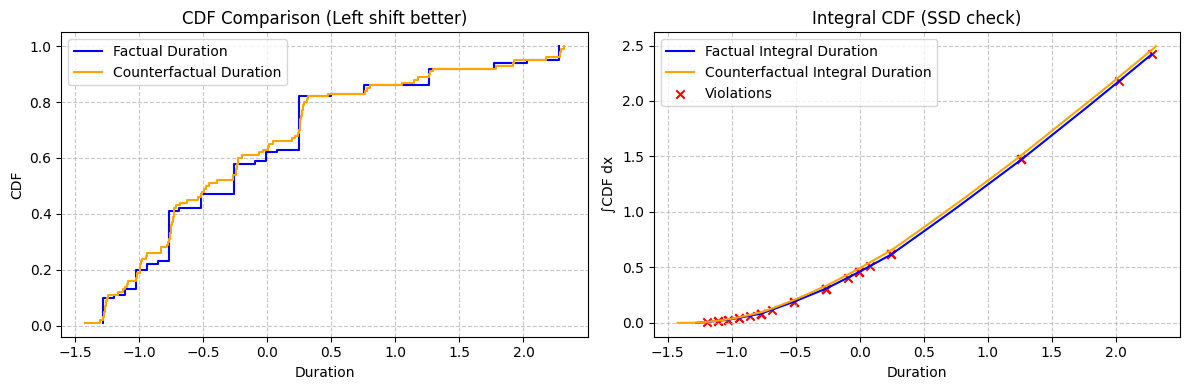

In [55]:
from explainers.constraints.SSDConstraint import SSDConstraintTorch
import matplotlib.pyplot as plt
import torch
# 设置设备，选择 GPU 或 CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# ================== Duration 分布对比 ==================
idx_duration = explain_columns.index("Duration")

# 获取 Duration 的正确列并转换为 PyTorch 张量，确保在相同设备上
fact_duration = torch.tensor(X_t[:, idx_duration], dtype=torch.float32).to(device)  # 将 fact_duration 转换为 PyTorch 张量
cf_duration = torch.tensor(X_s[:, idx_duration], dtype=torch.float32).to(device)  # 将 cf_duration 转换为 PyTorch 张量

# 检查是否满足 SSD
ssd_report = SSDConstraintTorch.check_SSD(
    fact_duration, cf_duration,
    tol=1e-8,
    return_violations=True,
    direction=-1  # Duration 越小越优
)

# 打印是否满足 SSD 约束
print("✅ 是否满足 SSD 约束 (Duration):", "是" if ssd_report["holds"] else "否")

# 如果不满足 SSD 约束，打印更多违规点信息
if not ssd_report["holds"]:
    print(f"❌ 违反点数量: {len(ssd_report['violations'])}")
    print(f"📊 满足比例: {ssd_report['point_ratio']:.3f}")

# 画 CDF + 积分曲线对比
SSDConstraintTorch.plot_cdf_with_integral(
    fact=fact_duration,
    cf=cf_duration,  # 确保 cf 参数传递给 plot_cdf_with_integral
    feature_name="Duration",
    direction=-1
)

In [56]:
import numpy as np
import torch
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager
# 注意：这里导入的是你的SSD约束类
from explainers.constraints.SSDConstraint import SSDConstraintTorch

# ================== 1. 定义 SSD 约束（Duration 左移更优） ==================
configs = [
    {
        "type": "ssd",  # 类型改为ssd
        "lambda": 10,  # 设置lambda=100（根据需求调整）
        "dir_map": {"Duration": -1},  # Duration 必须左移（与FSD保持一致）
        "M": 100,        # 采样50个factual点（训练用）
        "sample_mode": "quantile"
    }
]

# 使用与FSD相同的特征名
feature_names = list(df_explain.columns)
constraint_manager = ConstraintManager(configs=configs, feature_names=feature_names)

# ================== 2. 初始化带约束的 DCE ==================
set_seed(42)
explainer_ssd = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta,
    constraint_manager=constraint_manager
)

# ================== 3. 优化生成反事实 ==================
set_seed(42)
explainer_ssd.optimize(U_1=0.5, U_2=0.3, l=0.2, r=1, max_iter=50, tau=1e3)

X_s_ssd = explainer_ssd.best_X[:, explainer_ssd.explain_indices].clone().detach()

# ================== 4. 检查 SSD 条件 ==================
idx_duration = explain_columns.index("Duration")

# 提取事实分布和反事实分布的Duration特征
fact_duration = df_explain.iloc[:, idx_duration].values
cf_duration_ssd = X_s_ssd[:, idx_duration].cpu().numpy()

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.006234373088077394
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0470, term1=0.0289, term2=0.0298, penalty=0.017158858478069305
INFO:root:U_1-Qu_upper=0.42777121578409205, U_2-Qv_upper=0.22398929158135109
INFO:root:eta=0.7388122482444652, l=0.278, r=1
INFO:root:Iter 2: Q=0.0187, term1=0.0015, term2=0.0034, penalty=0.015763893723487854
INFO:root:U_1-Qu_upper=0.48951335809297947, U_2-Qv_upper=0.23103592710120946
INFO:root:eta=0.7684989177081505, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=0.0181, term1=0.0009, term2=0.0027, penalty=0.01583828032016754
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23924343877735055
INFO:root:eta=0.7780202487440562, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=0.0175, term1=0.0007, term2=0.0023, penalty=0.015566669404506683
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23745103701323872
INFO:root:eta=0.7901904327104041, l=0.38097525000000004, r=1
INFO:root:Iter 5:

生成带SSD约束的反事实，违反的点数降到33个。

✅ 带 SSD 约束：是否满足二阶随机占优(SSD): False
✅ 带 SSD 约束：违反点数量: 33
事实分布 Duration 均值: -0.1418624569986482
不带约束的反事实 Duration 均值: -0.180959090590477
SSD 约束反事实 Duration 均值: -0.17376914620399475
事实分布 CDF 曲线下的总面积: 2.4942028522491455
反事实分布 CDF 曲线下的总面积: 2.492778778076172


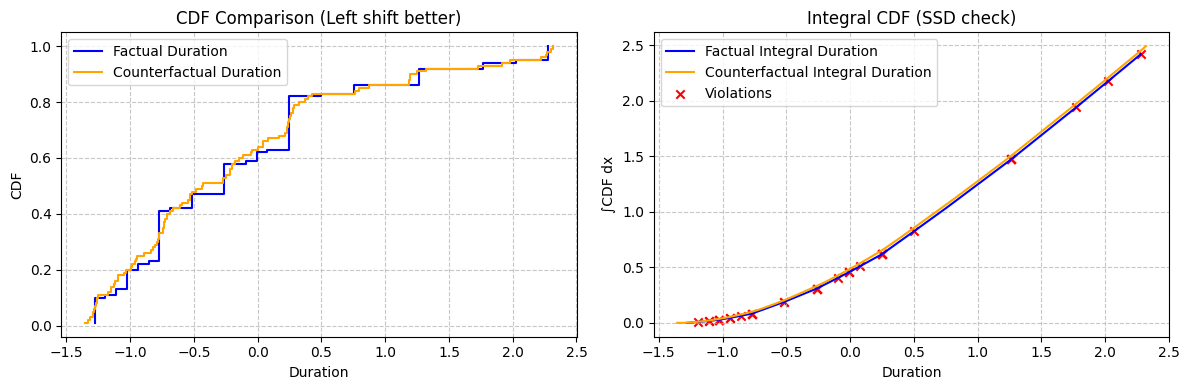

In [57]:
# 确保 fact_duration 和 cf_duration_ssd 是 PyTorch 张量，并且在相同设备上
fact_duration = torch.tensor(fact_duration) if not isinstance(fact_duration, torch.Tensor) else fact_duration
cf_duration_ssd = torch.tensor(cf_duration_ssd) if not isinstance(cf_duration_ssd, torch.Tensor) else cf_duration_ssd

# 确保在同一设备上
device = fact_duration.device  # 获取 fact_duration 所在设备
cf_duration_ssd = cf_duration_ssd.to(device)  # 将 cf_duration_ssd 移动到相同设备

# 调用SSD检查函数
result_ssd = SSDConstraintTorch.check_SSD(
    fact_duration, cf_duration_ssd,return_violations=True,
    direction=-1  # Duration 左移更优（与FSD保持一致）
)

# 直接访问字典的值（如果你不想使用 get()）
print("✅ 带 SSD 约束：是否满足二阶随机占优(SSD):", result_ssd["holds"])
print("✅ 带 SSD 约束：违反点数量:", len(result_ssd["violations"]))
# print("✅ 带 SSD 约束：点满足比例:", result_ssd["point_ratio"])
# print("✅ 带 SSD 约束：区间满足比例:", result_ssd["interval_ratio"])

# 使用 torch.mean() 计算 PyTorch 张量的均值
print("事实分布 Duration 均值:", torch.mean(fact_duration).item())
print("不带约束的反事实 Duration 均值:", torch.mean(cf_duration).item())
print("SSD 约束反事实 Duration 均值:", torch.mean(cf_duration_ssd).item())

# 计算 CDF 和积分
v_fact, A_fact, v_cf, A_cf = SSDConstraintTorch._compute_integrals(
    cf_duration, cf_duration_ssd, 
    sample_M=None,  # 绘图用全量数据，不抽样
    for_plot=True   # 返回numpy格式，适配绘图
)

# 获取总面积（积分曲线下的总面积）
total_area_fact = A_fact[-1]  # 事实分布的总面积
total_area_cf = A_cf[-1]      # 反事实分布的总面积

# 输出总面积
print(f"事实分布 CDF 曲线下的总面积: {total_area_fact}")
print(f"反事实分布 CDF 曲线下的总面积: {total_area_cf}")

# ================== 5. 画CDF+积分对比 ==================
SSDConstraintTorch.plot_cdf_with_integral(
    fact=fact_duration,
    cf=cf_duration_ssd,
    feature_name="Duration",
    direction=-1  # 保持方向一致
)

画出PDF对比，带有SSD约束的反事实分布（绿色）在事实分布（蓝色）密集的区域（大约在20附近）显著下降，表示反事实分布在这些密集区域避免产生过高的PDF值。这是为了减少违反SSD约束的风险。而在尾部区域，反事实分布的PDF值出现了较大的波动，导致在这些极值部分，PDF值较高。总体而言，反事实分布通过在密集区域减少PDF，并在尾部区域增加PDF，从而平衡了SSD约束的惩罚。

从惩罚项的角度来看，为了避免违反SSD约束，反事实分布在事实分布密集的区域会倾向于减少其分布，以避免产生过高的CDF积分。然而，为了平衡这一点，反事实分布可能会在事实分布稀疏的区域产生一些极值点。在这些稀疏区域，反事实分布可以有更大的波动，因为它们不会对CDF积分产生过大的影响。

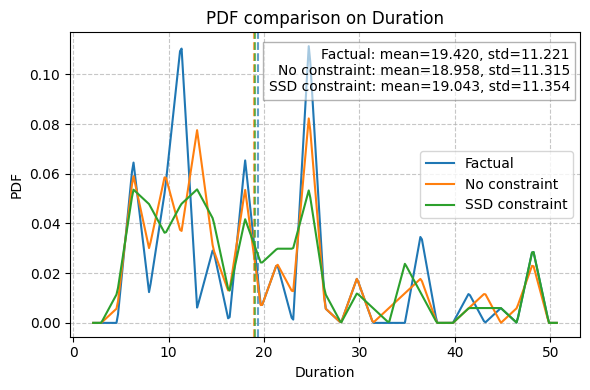

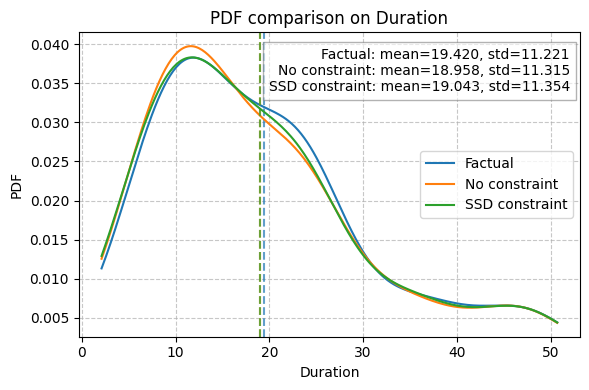

In [58]:
from utils.visualization import plot_pdf_column

# 绘制不平滑版本（直方图模式）
plot_pdf_column(
    datasets=[df_explain, X_s, X_s_ssd],
    column_name="Duration",
    labels=["Factual", "No constraint", "SSD constraint"],
    mean=mean["Duration"],
    std=std["Duration"],
    explain_columns=explain_columns,
    use_smoothing=False  # 禁用平滑（默认值，可省略）
)
# 在这些稀疏区域，反事实分布可以自由地调整，既不违背约束，也能在不受密集分布影响的情况下，通过“增加”这些稀疏区域的PDF值来弥补其他地方的分布偏移。这实际上是为了平衡约束和分布生成之间的关系，并不是为了“避免惩罚”而在极值部分特意增大PDF。

# 绘制平滑版本（KDE模式）
plot_pdf_column(
    datasets=[df_explain, X_s, X_s_ssd],
    column_name="Duration",
    labels=["Factual", "No constraint", "SSD constraint"],
    mean=mean["Duration"],
    std=std["Duration"],
    explain_columns=explain_columns,
    use_smoothing=True  # 启用平滑
)

In [60]:
# ================== X 空间 Wasserstein ==================
dist_X = np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())
dist_X_ssd = np.sqrt(explainer.swd.distance(X_s_ssd, X_t, delta)[0].item())

print(f"Wasserstein distance (X, 原始DCE vs 事实): {dist_X:.4f}")
print(f"Wasserstein distance (X, FSD-DCE vs 事实): {dist_X_ssd:.4f}")

# ================== y 空间 Wasserstein ==================
y_ssd = explainer_ssd.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(y, y_target, delta=delta)[0].item())
dist_y_ssd = np.sqrt(explainer.wd.distance(y_ssd, y_target, delta=delta)[0].item())

print(f"Wasserstein distance (y, 原始DCE vs 目标): {dist_y:.4f}")
print(f"Wasserstein distance (y, FSD-DCE vs 目标): {dist_y_ssd:.4f}")

Wasserstein distance (X, 原始DCE vs 事实): 0.0407
Wasserstein distance (X, FSD-DCE vs 事实): 0.0207
Wasserstein distance (y, 原始DCE vs 目标): 0.2280
Wasserstein distance (y, FSD-DCE vs 目标): 0.0335


# 附录：画图函数调用

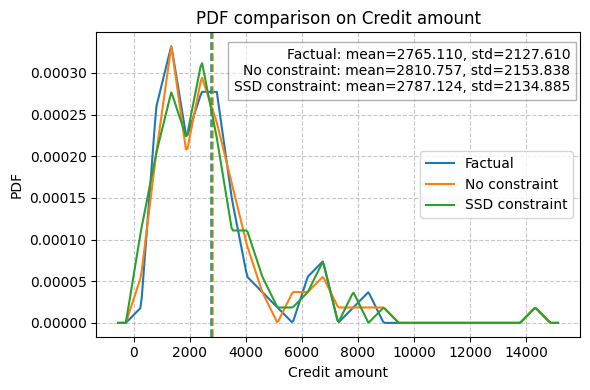

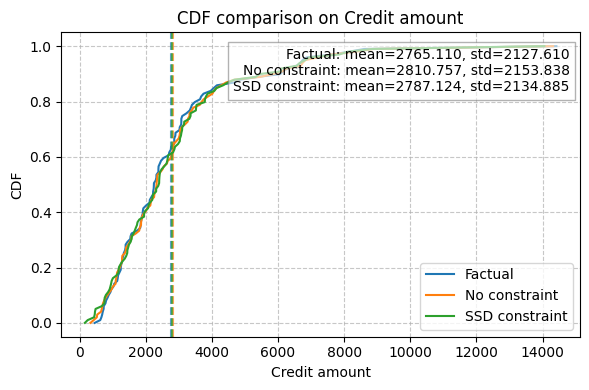

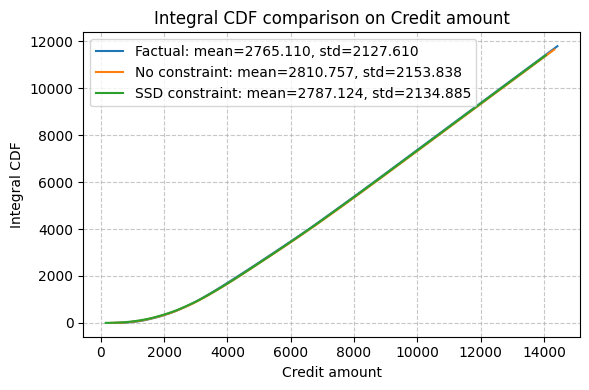

In [70]:
from utils.visualization import plot_pdf_column, plot_cdf_column, plot_integral_cdf_column
column_name = "Credit amount"  # 需要绘制的列
# ================== 1. 提取每一列的均值和标准差 ==================
# std_creditamount=std["Credit amount"]
# mean_creditamount=mean["Credit amount"]

std_creditamount=std[column_name]
mean_creditamount=mean[column_name]

explain_columns = df_explain.columns.tolist()  # 获取 DataFrame 的列名列表

# ================== 2. 设置数据集和列名 ==================
datasets = [df_explain, X_s, X_s_ssd]  # 包含原始数据，无约束反事实，带约束反事实


# ================== 3. 设置 smooth 参数 ==================
smooth = False  # 如果不平滑，设置为 False

# ================== 4. 绘制 PDF 曲线 ==================
plot_pdf_column(
    datasets=datasets,
    column_name=column_name,
    labels=["Factual", "No constraint", "SSD constraint"],
    explain_columns=explain_columns,  # 传递列名列表
    mean=mean_creditamount,  # 传递均值
    std=std_creditamount     # 传递标准差
)

# ================== 5. 绘制 CDF 曲线 ==================
plot_cdf_column(
    datasets=datasets,
    column_name=column_name,
    labels=["Factual", "No constraint", "SSD constraint"],
    explain_columns=explain_columns,  # 传递列名列表
    mean=mean_creditamount,  # 传递均值
    std=std_creditamount     # 传递标准差
)

# ================== 6. 绘制 CDF 积分曲线 ==================
plot_integral_cdf_column(
    datasets=datasets,
    column_name=column_name,
    labels=["Factual", "No constraint", "SSD constraint"],
    explain_columns=explain_columns,  # 传递列名列表
    mean=mean_creditamount,  # 传递均值
    std=std_creditamount     # 传递标准差
)
